In [1]:
!pip install numpy -q
!pip install scipy -q
!pip install matplotlib -q
!pip install statsmodels -q
!pip install pingouin -q

Para abrir con Google Colab: <a target="_blank" href="https://githubtocolab.com/SysBioengLab/IIQ3402-Statistical-Design/blob/main/Ayudantias/Ayudantia4_ztest_y_ttestats.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


# Distrubición t-Student

La distribución t-Student es una distribución de probabilidad importante en estadística debido a que esta nos permite realizar test sobre la población sin saber la desviación estándar de la mismo. En base a esto, utilizando el método de scipy que permite utilizar la
[distribución t](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.t.html).





## 1.
Si posee una muestra proveniente de una población con varianza desconocida con media $\overline{X}$ y desviación estándar muestral $S$. ¿Cuál es la expresión de para el t-crítico o *t-statistic*?

---
Respuesta:
El estadístico t se define por:
$$
T = \frac{\overline{X} - \mu_0}{S/\sqrt{n}}
$$

Y este sigue una distribución t parametrizada por $ddof = n-1$ con n la cantidad de datos.


## 2.
Utilizando 18 grados de libertad. ¿Calcule la probabilidad de que un valor sea menor a 3.9?


0.9994752916979689


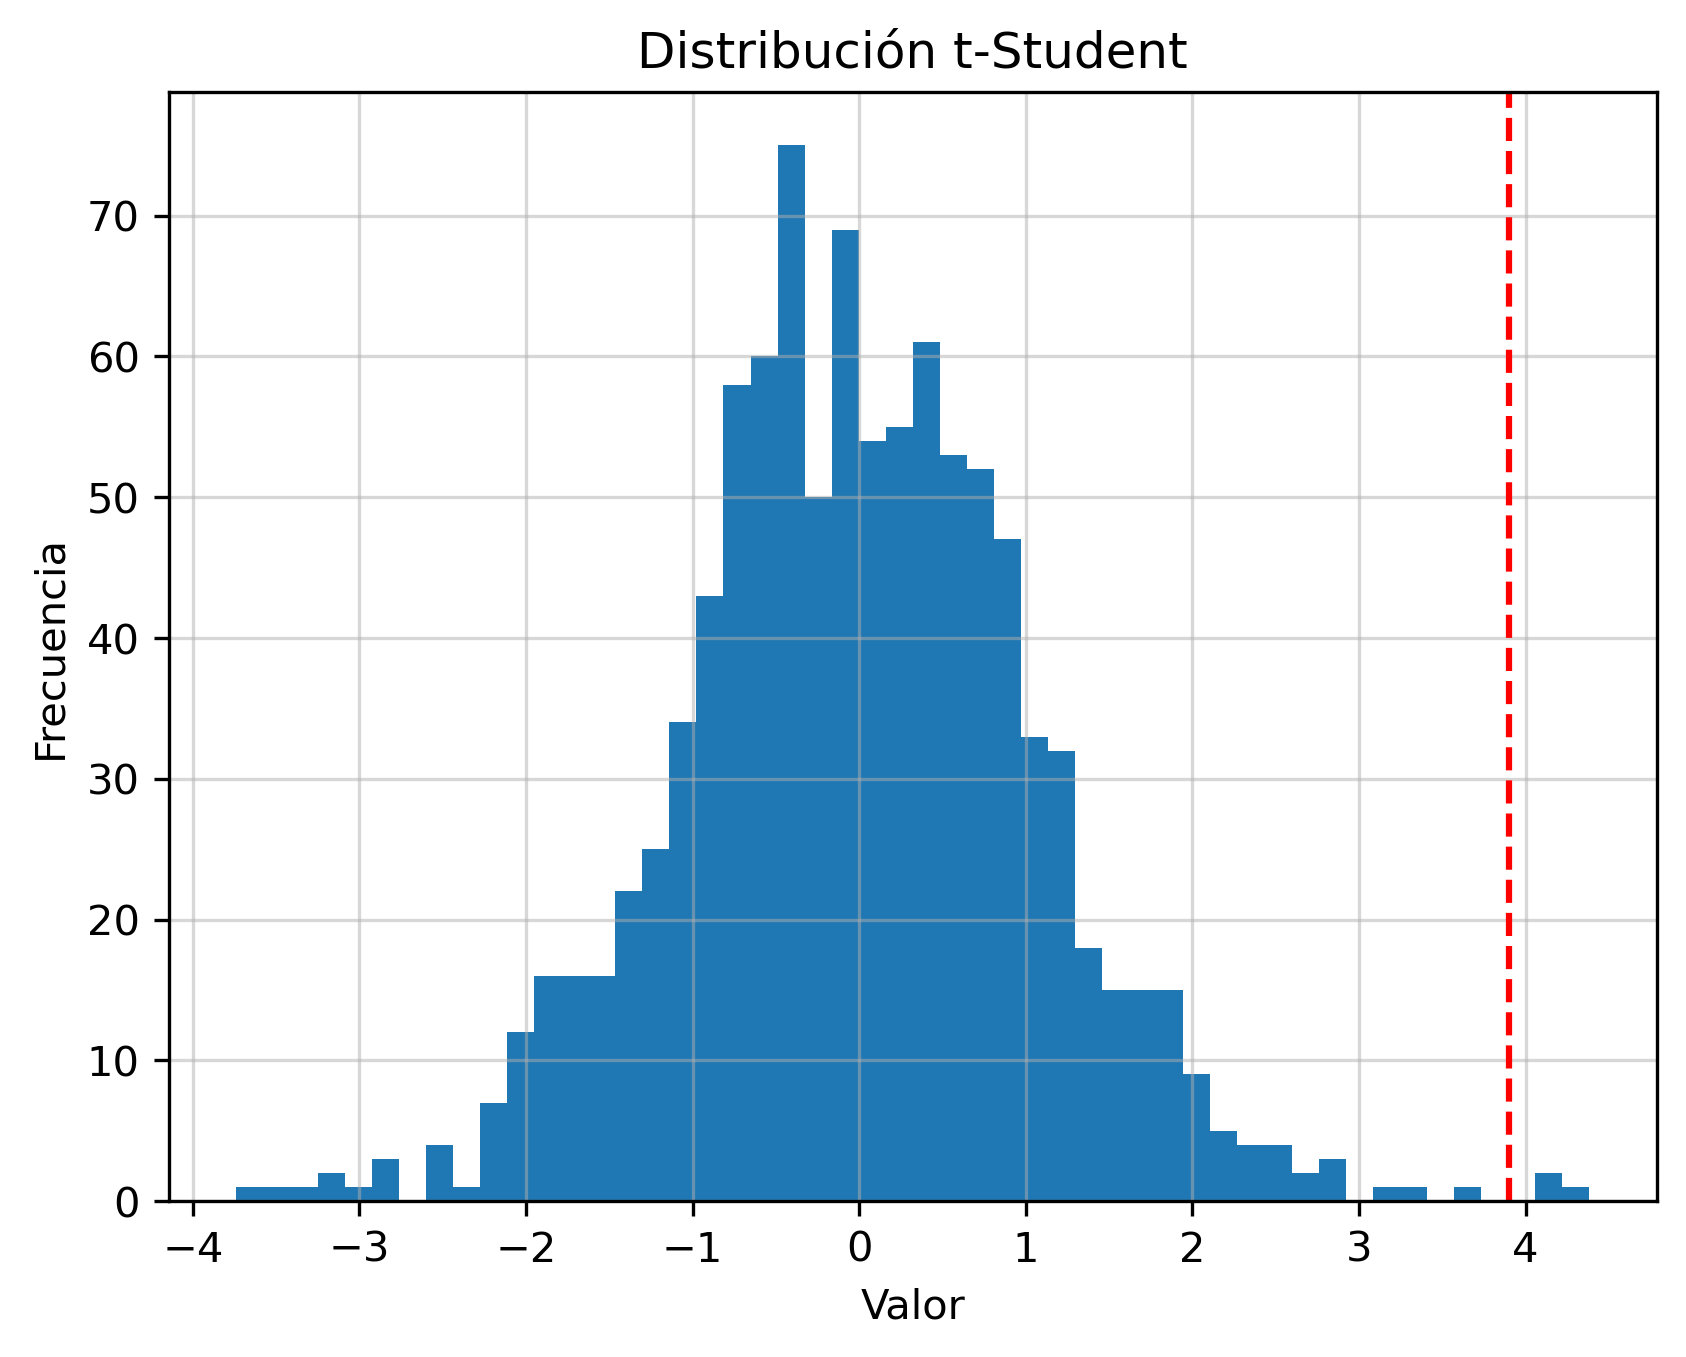

In [2]:
import scipy.stats as stats
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
df = 18
prob = stats.t.cdf(3.9, df = df)
print(prob)
rand_num = stats.t.rvs(df, size=1_000)

fig, ax = plt.subplots(dpi = 300)
ax.hist(rand_num, bins=50)
ax.set_title('Distribución t-Student')
ax.set_xlabel('Valor')
ax.set_ylabel('Frecuencia')
ax.grid(True, alpha = 0.5)
ax.axvline(x=3.9, color='red', linestyle='--')
plt.show()

## 3.
Utilizando 5 grados de libertad. ¿Calcule la la densidad de probabilidad evaluada en 1.1?

0.19813859080334623


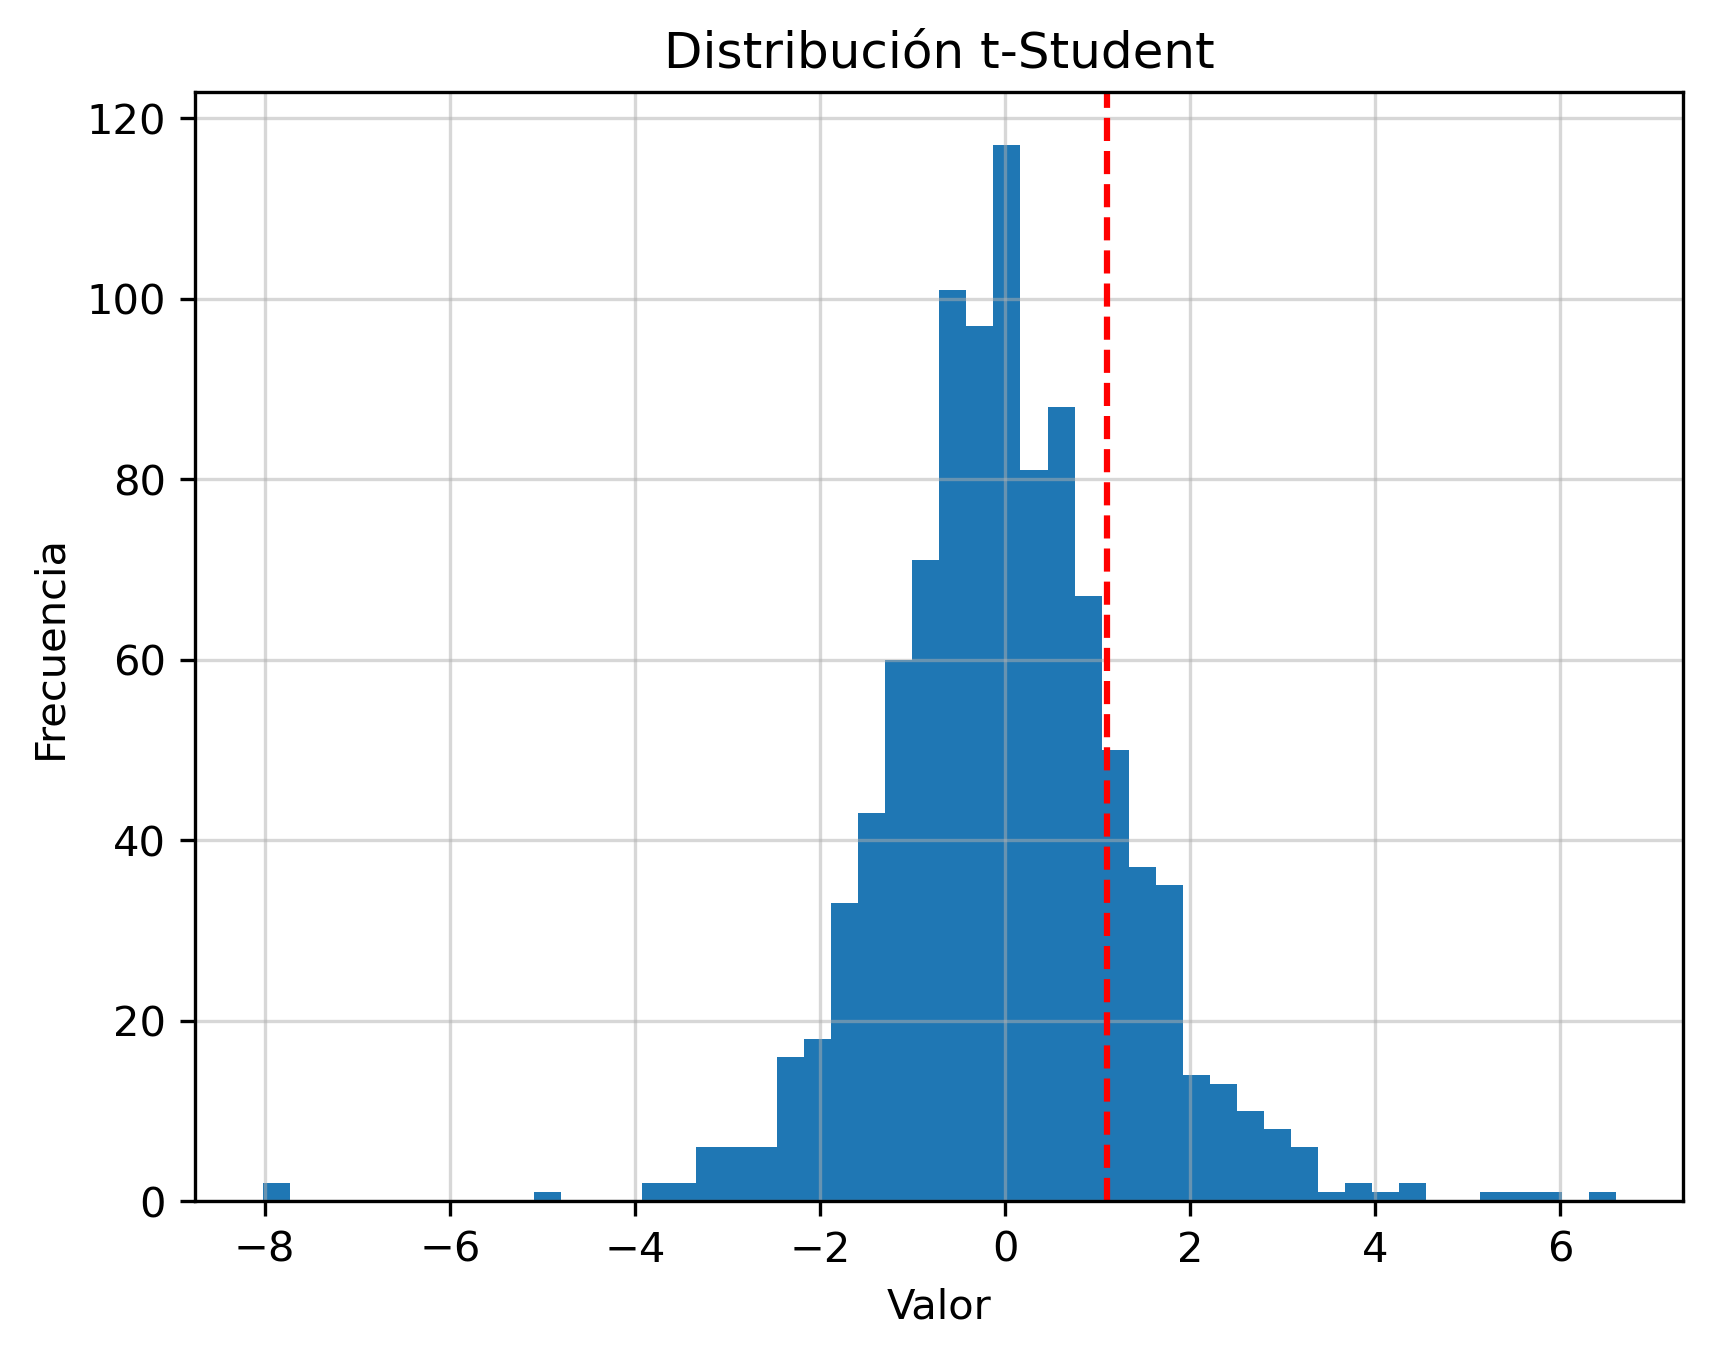

In [3]:

df = 5
prob = stats.t.pdf(1.1, df = df)
print(prob)
rand_num = stats.t.rvs(df, size=1_000)
fig, ax = plt.subplots(dpi = 300)
ax.hist(rand_num, bins=50)
ax.set_title('Distribución t-Student')
ax.set_xlabel('Valor')
ax.set_ylabel('Frecuencia')
ax.grid(True, alpha = 0.5)
ax.axvline(x=1.1, color='red', linestyle='--')
plt.show()

## 4.

Utilizando 12 grados de libertad. ¿Calcule el intervalo de confianza de 97.5\% de confianza para un t-crítico definido por esta probabilidad?

---
Respuesta:

$$
\alpha = 1 - 0.975 = 0.025
$$
Ahora debemos calcular $t_{\alpha/2, n-1}$

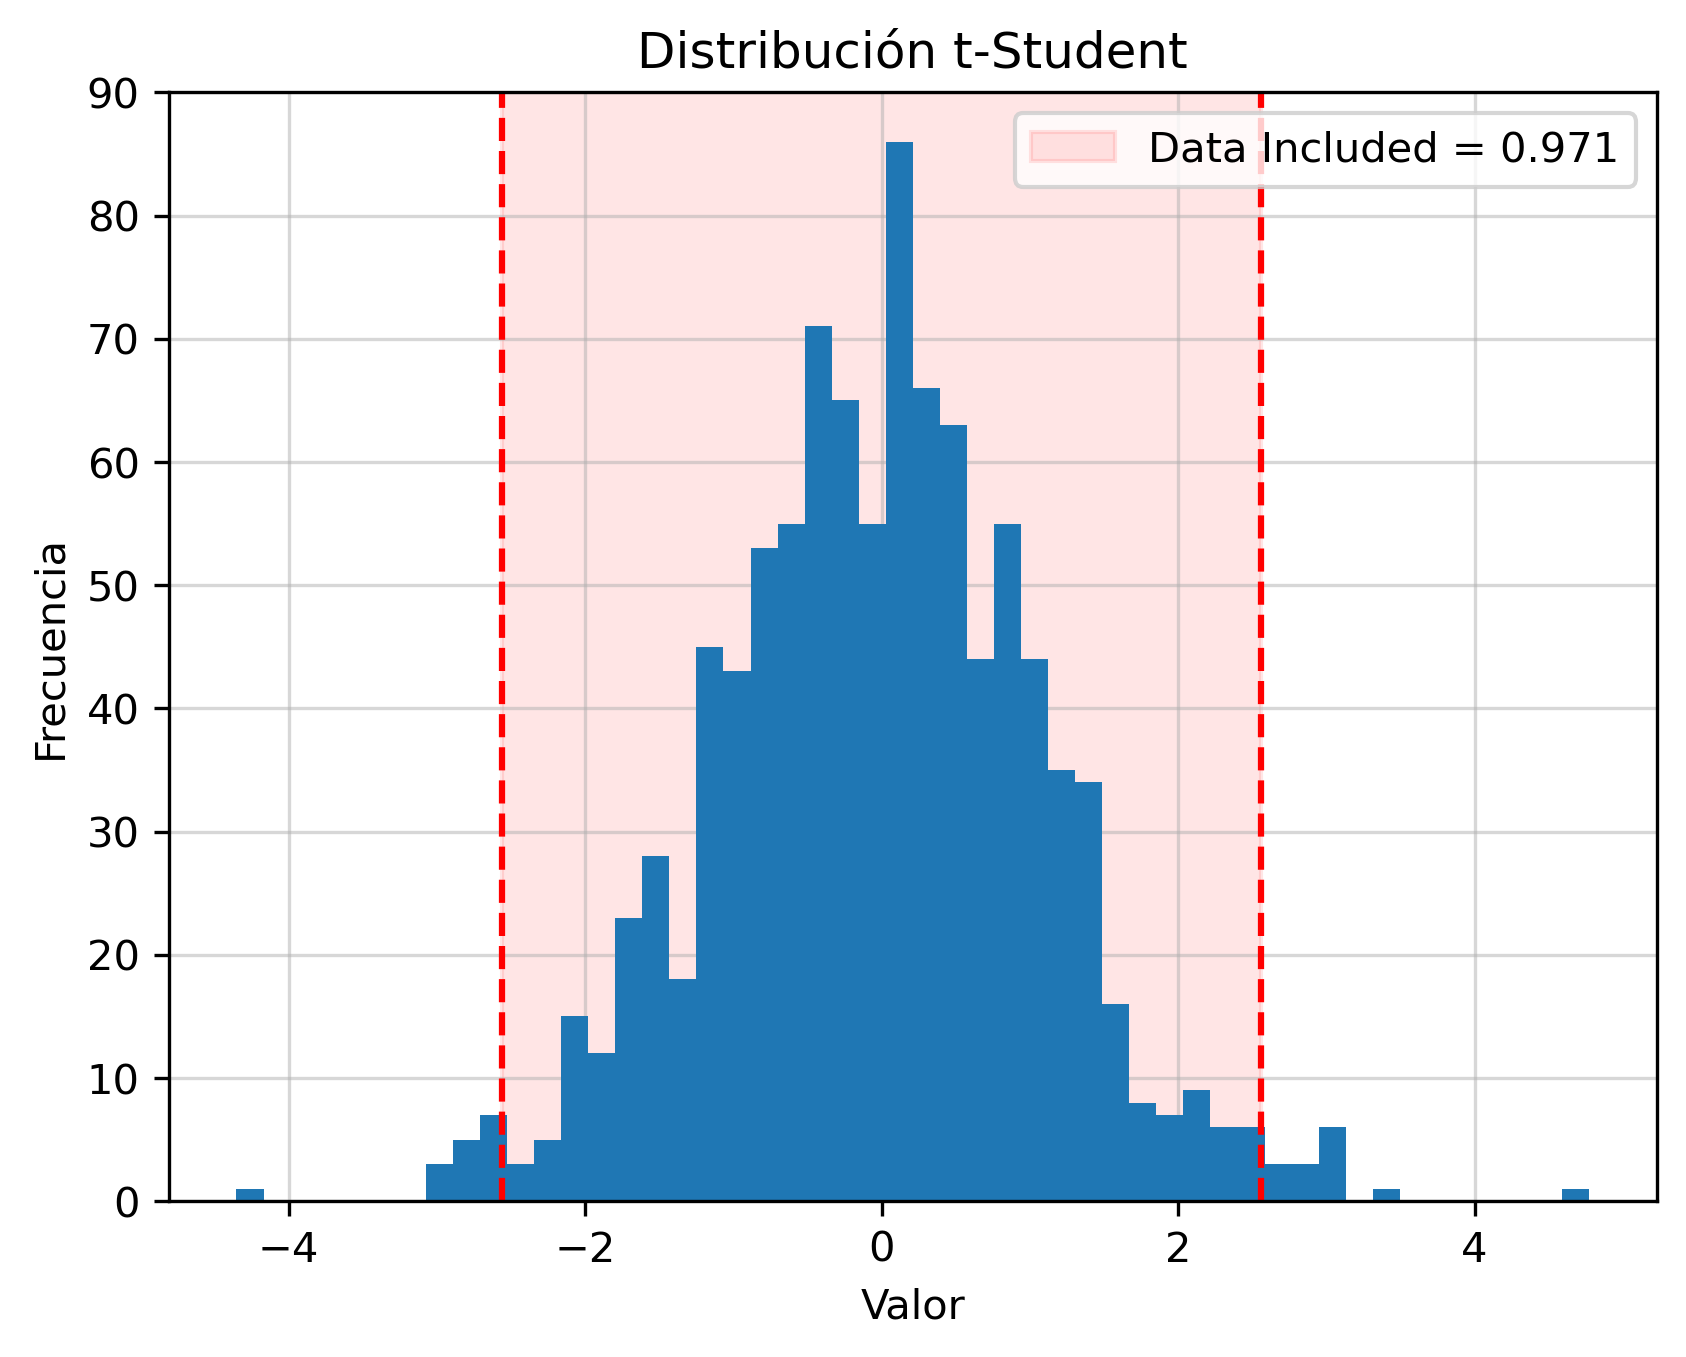

In [4]:
np.random.seed(42)
alpha = 0.025
df = 12
t_ci_sup = stats.t.ppf(1-alpha/2, df)
t_ci_inf = stats.t.ppf(alpha/2, df)

rand_num = stats.t.rvs(df, size=1_000)
fig, ax = plt.subplots(dpi = 300)

proportion = np.mean((rand_num < t_ci_sup) & (rand_num > t_ci_inf))

ax.hist(rand_num, bins=50, zorder = 2)
ax.set_title('Distribución t-Student')
ax.set_xlabel('Valor')
ax.set_ylabel('Frecuencia')
ax.grid(True, alpha = 0.5)
ax.axvline(x=t_ci_sup, color='red', linestyle='--')
ax.axvline(x=t_ci_inf, color='red', linestyle='--')
ax.fill_between([t_ci_inf, t_ci_sup], [90, 90], alpha=0.1, color='red', zorder = 1,
                label = f'Data Included = {proportion}')
ax.legend(loc='upper right')
ax.set_ylim(0, 90)
plt.show()
plt.show()


## 5.

Verifique como se comporta la distribución de probabilidad a medida que aumentan los grados de libertad. ¿Cómo se compara la distribución t-Student con una distribución normal a medida que aumentan los grados de libertad?

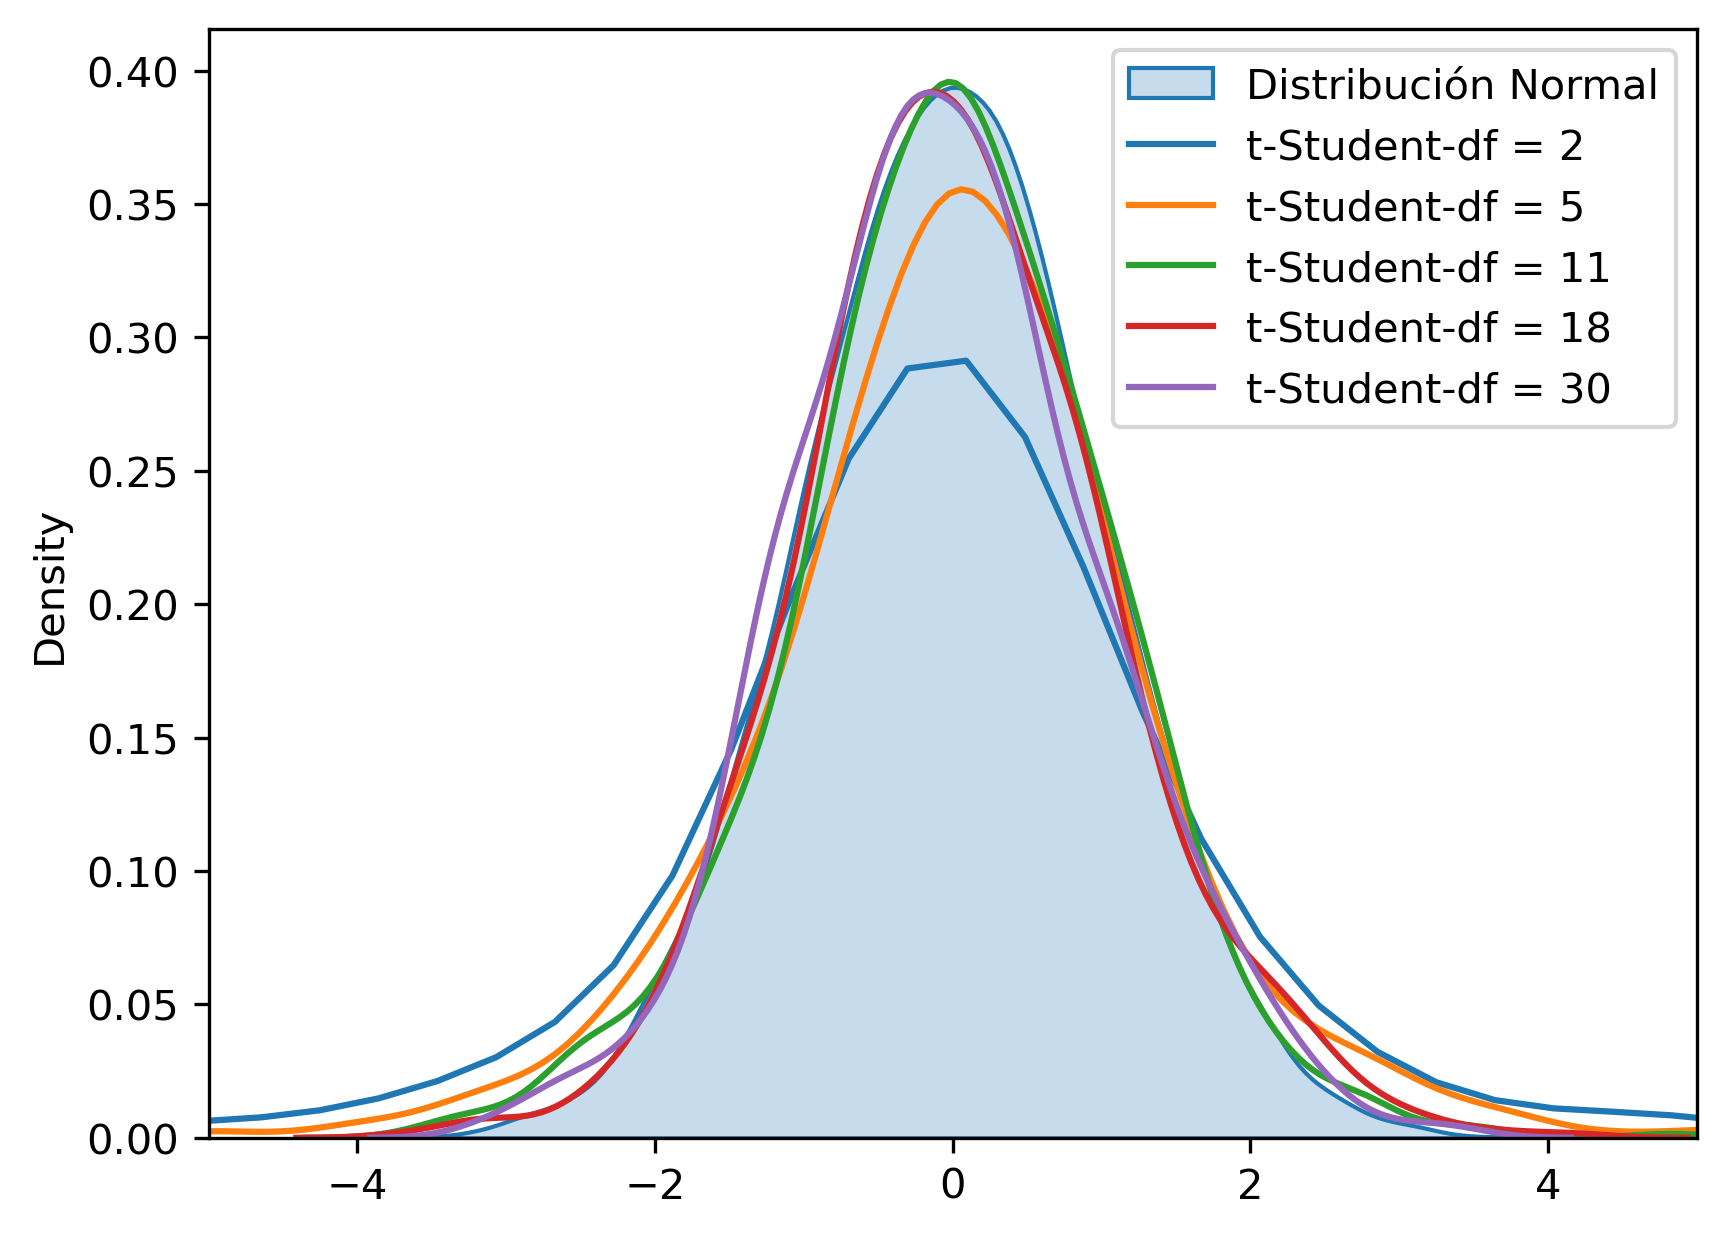

In [5]:
np.random.seed(42)
df_array = [2,5,11,18,30]
fig, ax = plt.subplots(dpi = 300)
num_normal = np.random.normal(size=10_000)
sns.kdeplot(num_normal, ax=ax, label='Distribución Normal', fill=True)
for i in df_array:
    t_student = stats.t.rvs(i, size=1_000)
    sns.kdeplot(t_student, ax=ax, label=f't-Student-df = {i}', fill=False)
ax.set_xlim(-5,5)
ax.legend(loc='upper right')
plt.show()



Podemos ver como la distribución t-Student a medida que se incrementan los grados de libertad, más esta se acerca a una distribución normal.

# Royal Gala 2.0
Al Viejo MacDonald le gustó el trabajo que realizó previamente y le gustaría que realizara otros análisis. Recordemos que los datos fueron recolectados de la siguinte forma: De cada huerto (1 huerto = 1 muestra), se seleccionaron 5 árboles al azar, y de cada árbol se tomaron 20 manzanas de tres secciones distintas de árbol (parte alta, media y baja de la copa), esto para una temporada. Además, según internet, el peso promedio de una manzana es de 149 g (otras fuentas clasifican a los tamaños como grande, mediano y pequeño, con pesos de 215 g, 169 g y 120 g, respectivamente), y una desviación estándar de 28 g.

## 1.
El vecino del Viejo MacDonald no quedo conforme con su análisis anterior. Sabiendo que el promedio de su huerto es de 150 g, considerando que de su huerto se obtuvieron 30 manzanas:


### a.

Realice un test de hipótesis y calcule la probabilidad de cometer un error del tipo I y tipo II. ¿Qué se puede concluir al respecto?

---
Respuesta:

Debido a que conocemos la desviación estándar poblacional ($\sigma = 28$) podemos realizar un z-testats.

$H_0: \mu = \mu_0$

$H_a: \mu > \mu_0$

Donde $\mu_0 = 149$

In [ ]:
mu = 150
mu0 = 149
sigma = 28
alpha = 0.05
n = 30
# error tipo I
z_stastistic = (mu - mu0)/(sigma/np.sqrt(n)) # calculamos el estadistico z
# recordemos z_0 = mu - mu0 / (sigma/sqrt(n)) 
# donde mu es la media muestral, mu0 es la media bajo la hipotesis nula, 
# sigma es la desviacion estandar poblacional y n es el tamaño de la muestra
# valor p
# para una prueba de una cola (greater) mu > mu0
# p_val = 1 - stats.norm.cdf(z_stastistic) 
# para una prueba de una cola (less) mu < mu0
# p_val = stats.norm.cdf(z_stastistic)
# para una prueba de dos colas mu != mu0
# p_val = 2*(1-stats.norm.cdf(np.abs(z_stastistic)))

p_val_g = 1 - stats.norm.cdf(z_stastistic) # greater
p_val_2s = 2*(1-stats.norm.cdf(np.abs(z_stastistic))) # two-sided

# Error tipo II
# para una prueba de dos colas mu != mu0
# definimos delta como la diferencia entre la media muestral y la media bajo la hipotesis nula
# notar que este delta puede ser definido con cualquier valor de mu, pero en este caso se define con la media muestral
# define que tan sensible es la prueba a detectar una diferencia entre la media muestral y la media bajo la hipotesis nula
delta = mu - mu0 

# recordemos que el error tipo II es la probabilidad de no rechazar la hipotesis nula cuando esta es falsa
# este se calcula como se ve abajo (ver torpero para mas informacion :))
z_alpha2 = stats.norm.ppf(1 - 0.05/2) 


beta_2s = stats.norm.cdf(
    z_alpha2 - (delta * np.sqrt(n)/sigma)
) - stats.norm.cdf(
    - z_alpha2 - (delta * np.sqrt(n)/sigma)
)

# de manera similar, para una prueba de una cola mu > mu0
z_alpha = stats.norm.ppf(1 - 0.05)
beta_g = stats.norm.cdf(
    z_alpha - (delta * np.sqrt(n)/sigma)
)

print('-------Two-Sided-------')
print(f'p-value (tipo I): {p_val_2s:.2f}')
print(f'beta (tipo II): {beta_2s:.2f}\n')
print('-------One-Sided-------')
print(f'p-value (tipo I): {p_val_g:.2f}')
print(f'beta (tipo II): {beta_g:.2f}')

-------Two-Sided-------
p-value (tipo I): 0.00
beta (tipo II): 0.00

-------One-Sided-------
p-value (tipo I): 0.00
beta (tipo II): 0.00


### b.
Dado los resultados, el vecino le da 30 manzanas más (n = 60) ¿Hay algún cambio en las probabilidades anteriores?

In [7]:
mu = 150
mu0 = 149
sigma = 28
alpha = 0.05
n = 60 # cambiamos n desde 30 a 60 
# error tipo I
z_stastistic = (mu - mu0)/(sigma/np.sqrt(n))

p_val_g = 1 - stats.norm.cdf(z_stastistic) # greater
p_val_2s = 2*(1-stats.norm.cdf(np.abs(z_stastistic)))
delta = mu - mu0
z_alpha2 = stats.norm.ppf(1 - 0.05/2)

# error del tipo II
beta_2s = stats.norm.cdf(
    z_alpha2 - (delta * np.sqrt(n)/sigma)
) - stats.norm.cdf(
    - z_alpha2 - (delta * np.sqrt(n)/sigma)
)
z_alpha = stats.norm.ppf(1 - 0.05)
beta_g = stats.norm.cdf(
    z_alpha - (delta * np.sqrt(n)/sigma)
)

print('-------Two-Sided-------')
print(f'p-value (tipo I): {p_val_2s:.2f}')
print(f'beta (tipo II): {beta_2s:.2f}')
print('-------One-Sided-------')
print(f'p-value (tipo I): {p_val_g:.2f}')
print(f'beta (tipo II): {beta_g:.2f}')

-------Two-Sided-------
p-value (tipo I): 0.78
beta (tipo II): 0.94
-------One-Sided-------
p-value (tipo I): 0.39
beta (tipo II): 0.91


### c.
¿Cuál es la cantidad de manzanas que se deben utilizar para obtener un poder estadístico $(1-\beta)$ de 90\% dada una significancia de $\alpha = 0.05$ y $\delta = 1$?

In [8]:
# utilizando one sided alterative
beta = 1 - 0.9 # 1-beta = 0.9 -> beta = 1 - 0.9
alpha = 0.05 # significancia
delta = 1 # nivel de diferencia que se quiere detectar (150 - 149)

z_alpha = stats.norm.ppf(alpha) # calculamos el valor critico para alpha
z_beta = stats.norm.ppf(beta) # calculamos el valor critico para beta
sigma = 28 # desviacion estandar poblacional 

n = (((z_alpha + z_beta)**2 ) * sigma**2)/(delta**2)
# calculamos el el tamaño de muestra necesario para detectar una diferencia de 1 con una potencia del 90% y un nivel de significancia del 5%
print(f'n = {n:.2f}')

n = 6714.06


### d.

No conforme con esto, el vecino del Viejo MacDonald quiere un análisis más exhaustivo así que le pide construir la *Operating Characteristic Curve* de su huerto. Construya dicha curva para niveles de significancia $\alpha = 0.1$, $\alpha = 0.05$, $\alpha = 0.01$ y $\alpha = 0.001$.

Recordemos que las OC curves grafican la diferencia que se puede detectar, la probabilidad de tipo II y el tamaño de muestra para diferentes $\alpha$. Esto permite diseñar el tamaño de muestra con tal de obtener propiedades estadísticas que se requieren.

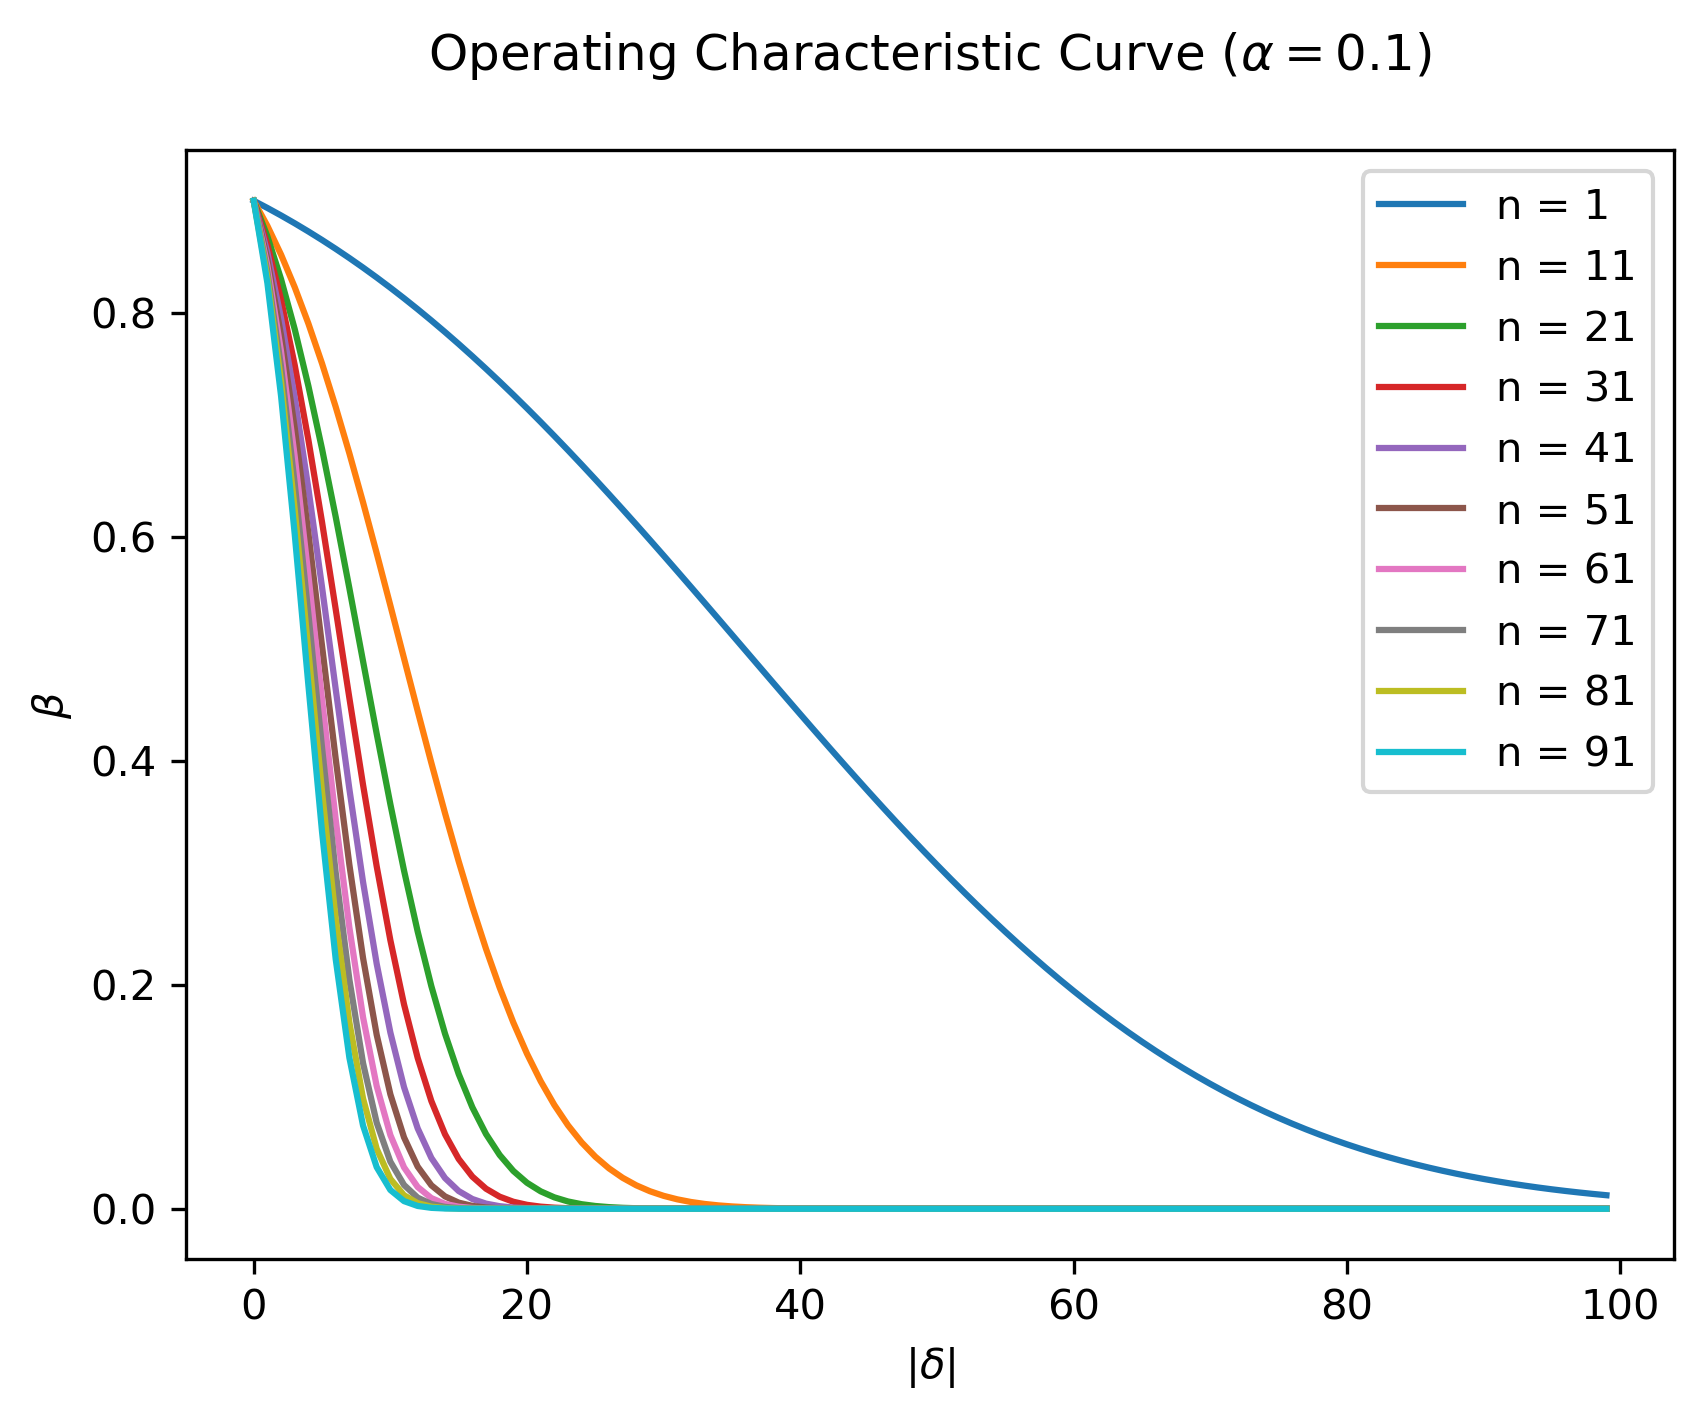

In [9]:
alphas =  0.1 # significancia

deltas = np.arange(0, 100, 1) # valores de delta entre 0 y 100 con un paso de 1
sigma = 28 # desviacion estandar poblacional
fig, ax = plt.subplots(dpi = 300)
n_s = np.arange(1, 100, 10)  # tamaños de muestra entre 1 y 100 con un paso de 10
z_alpha = stats.norm.ppf(1 - alphas) # computamos el valor critico para alpha
for n in n_s: # iteramos por cada valor de n
    beta_a = [] # guardamos los valores de beta para cada delta
    for d in deltas:
        beta_g = stats.norm.cdf( # calculamos el valor de beta para cada delta y cada n
            z_alpha - (d * np.sqrt(n)/sigma) # usamos la formula de beta para una prueba de una cola (greater)  
        )
        beta_a.append(beta_g) # guardamos el valor de beta para cada delta
 
    ax.plot(deltas, beta_a, label = f'n = {n}')  # graficamos beta vs delta para cada n

# labels
ax.set_xlabel(r'$|\delta|$')
ax.set_ylabel(r'$\beta$')
ax.set_title(r'Operating Characteristic Curve ($\alpha = 0.1$)', y = 1.05)

ax.legend()
plt.show()




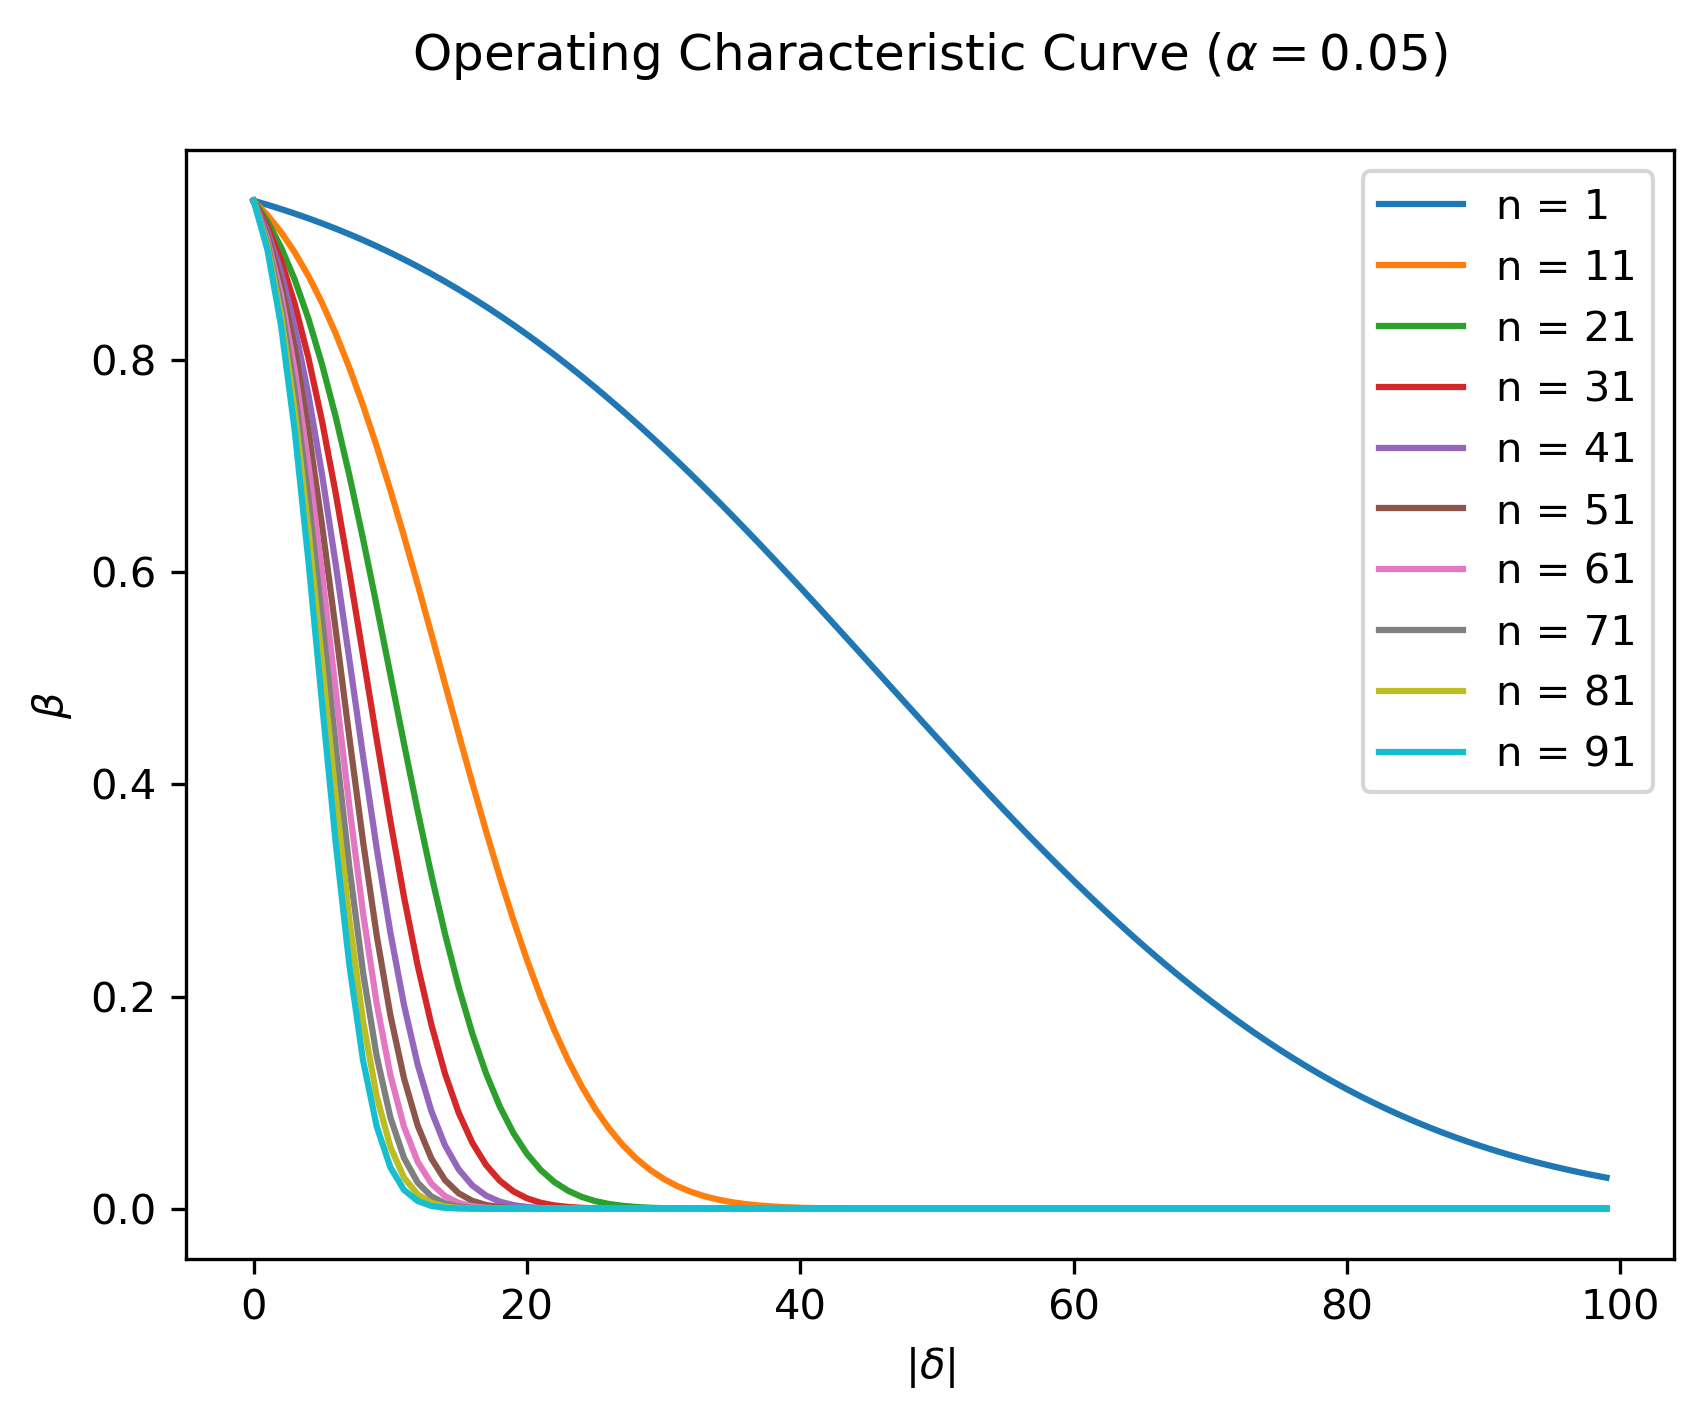

In [10]:
alphas =  0.05 # significancia

deltas = np.arange(0, 100, 1) # valores de delta entre 0 y 100 con un paso de 1
sigma = 28 # desviacion estandar poblacional
fig, ax = plt.subplots(dpi = 300)
n_s = np.arange(1, 100, 10)  # tamaños de muestra entre 1 y 100 con un paso de 10
z_alpha = stats.norm.ppf(1 - alphas) # computamos el valor critico para alpha
for n in n_s: # iteramos por cada valor de n
    beta_a = [] # guardamos los valores de beta para cada delta
    for d in deltas:
        beta_g = stats.norm.cdf( # calculamos el valor de beta para cada delta y cada n
            z_alpha - (d * np.sqrt(n)/sigma) # usamos la formula de beta para una prueba de una cola (greater)  
        )
        beta_a.append(beta_g) # guardamos el valor de beta para cada delta
 
    ax.plot(deltas, beta_a, label = f'n = {n}')  # graficamos beta vs delta para cada n

# labels
ax.set_xlabel(r'$|\delta|$')
ax.set_ylabel(r'$\beta$')
ax.set_title(r'Operating Characteristic Curve ($\alpha = 0.05$)', y = 1.05)

ax.legend()
plt.show()


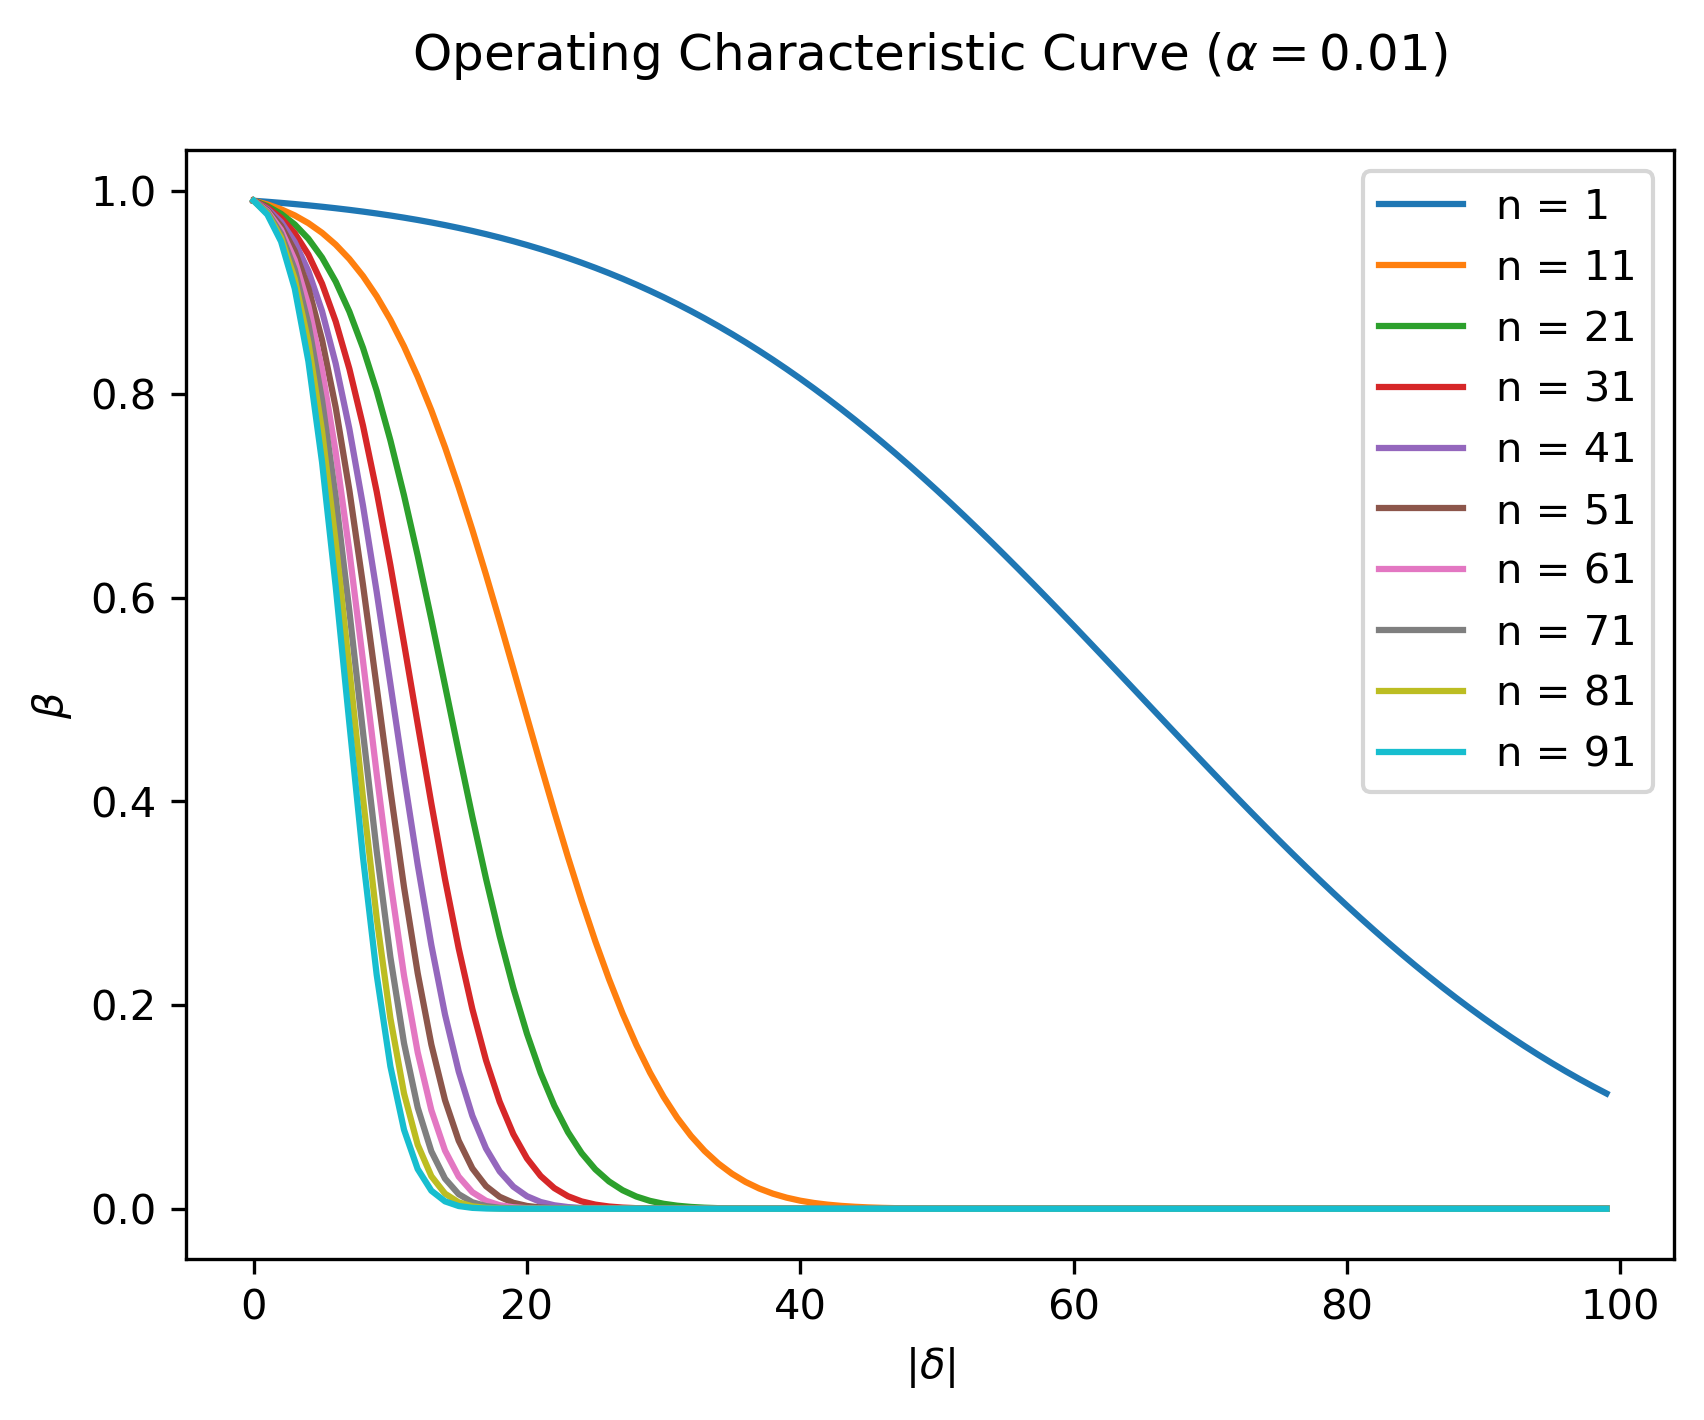

In [11]:
alphas =  0.01 # significancia

deltas = np.arange(0, 100, 1) # valores de delta entre 0 y 100 con un paso de 1
sigma = 28 # desviacion estandar poblacional
fig, ax = plt.subplots(dpi = 300)
n_s = np.arange(1, 100, 10)  # tamaños de muestra entre 1 y 100 con un paso de 10
z_alpha = stats.norm.ppf(1 - alphas) # computamos el valor critico para alpha
for n in n_s: # iteramos por cada valor de n
    beta_a = [] # guardamos los valores de beta para cada delta
    for d in deltas:
        beta_g = stats.norm.cdf( # calculamos el valor de beta para cada delta y cada n
            z_alpha - (d * np.sqrt(n)/sigma) # usamos la formula de beta para una prueba de una cola (greater)  
        )
        beta_a.append(beta_g) # guardamos el valor de beta para cada delta
 
    ax.plot(deltas, beta_a, label = f'n = {n}')  # graficamos beta vs delta para cada n

# labels
ax.set_xlabel(r'$|\delta|$')
ax.set_ylabel(r'$\beta$')
ax.set_title(r'Operating Characteristic Curve ($\alpha = 0.01$)', y = 1.05)

ax.legend()
plt.show()





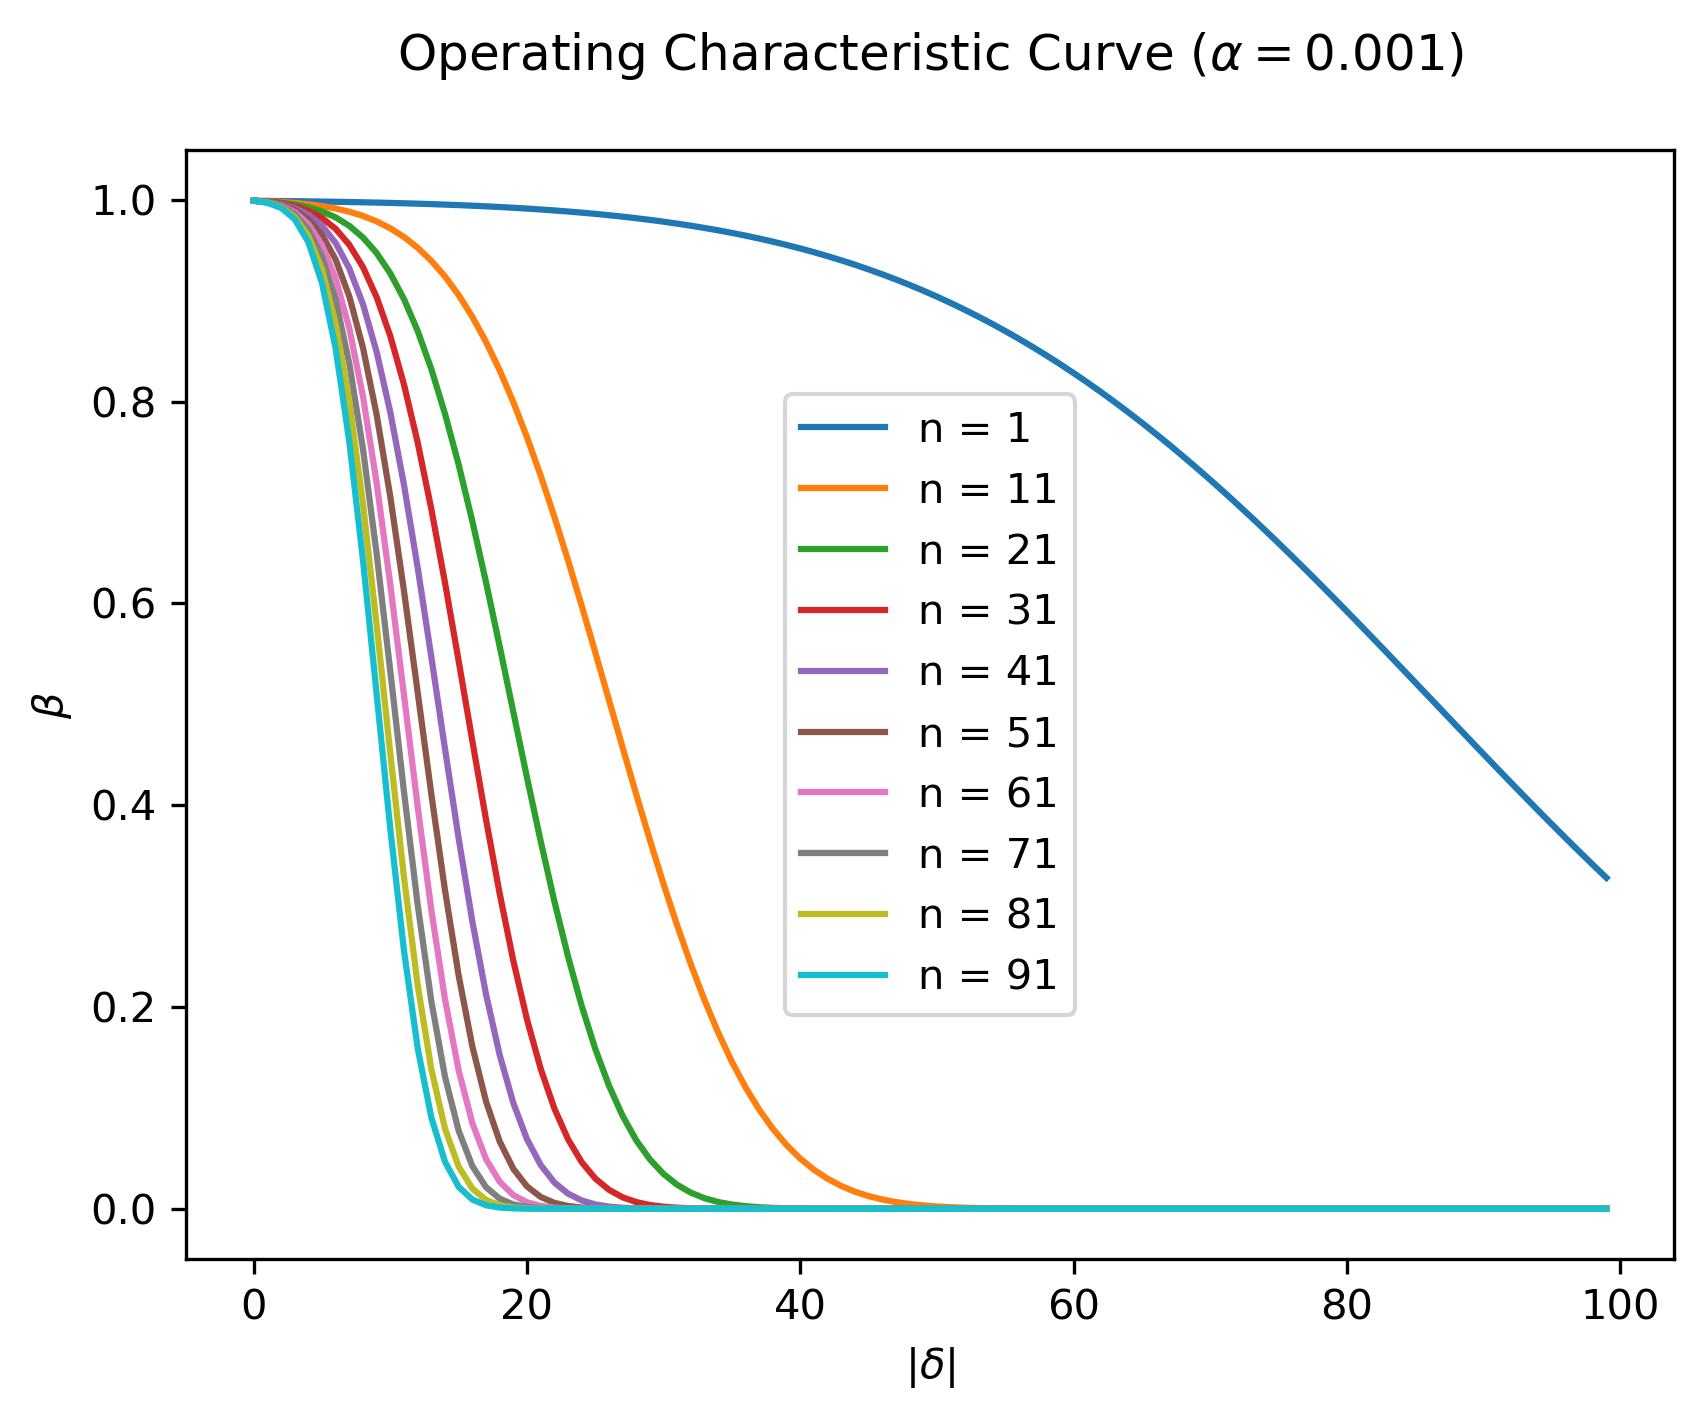

In [12]:
alphas =  0.001 # significancia

deltas = np.arange(0, 100, 1) # valores de delta entre 0 y 100 con un paso de 1
sigma = 28 # desviacion estandar poblacional
fig, ax = plt.subplots(dpi = 300)
n_s = np.arange(1, 100, 10)  # tamaños de muestra entre 1 y 100 con un paso de 10
z_alpha = stats.norm.ppf(1 - alphas) # computamos el valor critico para alpha
for n in n_s: # iteramos por cada valor de n
    beta_a = [] # guardamos los valores de beta para cada delta
    for d in deltas:
        beta_g = stats.norm.cdf( # calculamos el valor de beta para cada delta y cada n
            z_alpha - (d * np.sqrt(n)/sigma) # usamos la formula de beta para una prueba de una cola (greater)  
        )
        beta_a.append(beta_g) # guardamos el valor de beta para cada delta
 
    ax.plot(deltas, beta_a, label = f'n = {n}')  # graficamos beta vs delta para cada n

# labels
ax.set_xlabel(r'$|\delta|$')
ax.set_ylabel(r'$\beta$')
ax.set_title(r'Operating Characteristic Curve ($\alpha = 0.001$)', y = 1.05)

ax.legend()
plt.show()







## 2.
Después de su análisis,  una tormenta afectó a los diferentes cultivos de la zona. Los granjeros de la zona le solicitan que analice sus cultivos para evaluar si se mantienen por sobre el promedio poblacional. Gracias a la catástrofe, la desviación estándar de la población cambió -y no la sabe. Realice iterativamente test estadísticos para evaluar los cambios.

Calcule el estadístico de su prueba, el valor-p, intervalos de confianza y si puede o no rechazar la hipótesis nula. Sus datos son:



```
gala = [[150, 12, 31],[140, 21, 43], [155, 23, 12], [145, 23, 31],
[122,50, 13], [200, 31, 12], [144, 12, 21]]
```

Considere que la primera entrada es la media de la muestra, la segunda es la desviación
estándar y la tercera es la cantidad de datos en la muestra. Antes de empezar, considere qué
test debe utilizar.



In [13]:
gala = [[150, 12, 31],[140, 21, 43], [155, 23, 12], [145, 23, 31],
[122,50, 13], [200, 31, 12], [144, 12, 21]] 
# set de datos, recordemso que cada item es media, std, n



# Hipótesis
# H0: media = 149
# Ha: media > 149
# generamos un dataframe para guardar los resultados
data_result = pd.DataFrame(columns = ['Media', 'Std', 'n', 't0',
                                      'valor-p','CI_Low','CI_High'])
# iteramos por cada set de datos
# for i,(media, desviacion, n_i) in enumerate(gala): 
# # lo que hace esto es iterar por cada set de datos en gala y asignar cada valor a media, desviacion y n_i respectivamente
# ademas de asignar un indice i para cada iteracion, esto nos permite guardar los resultados en el dataframe data_result
mu0 = 149 # 
for i, (mu, sigma, n_i) in enumerate(gala): 
    

    t_stat = (mu - mu0)/(sigma/np.sqrt(n_i)) # estadistico t
    p_val = 1 - stats.t.cdf(t_stat, df = n_i-1) # valor p para una prueba de una cola (greater)
    t_alpha2 = stats.t.ppf(1 - 0.05/2, df = n_i-1) # valor critico para una prueba de dos colas con alpha = 0.05
    ci_low = mu - t_alpha2 * (sigma/np.sqrt(n_i)) # limite inferior del intervalo de confianza
    ci_high = mu + t_alpha2 * (sigma/np.sqrt(n_i)) # limite superior del intervalo de confianza

    data_result.loc[i] = [mu, sigma, n_i, t_stat, p_val, ci_low, ci_high]
pd.options.display.float_format = '{:.4f}'.format
data_result




,Media,Std,n,t0,valor-p,CI_Low,CI_High
0,150.0000,12.0000,31.0000,0.4640,0.3230,145.5984,154.4016
1,140.0000,21.0000,43.0000,-2.8103,0.9963,133.5372,146.4628
2,155.0000,23.0000,12.0000,0.9037,0.1928,140.3865,169.6135
3,145.0000,23.0000,31.0000,-0.9683,0.8297,136.5635,153.4365
4,122.0000,50.0000,13.0000,-1.9470,0.9623,91.7853,152.2147
5,200.0000,31.0000,12.0000,5.6990,0.0001,180.3035,219.6965
6,144.0000,12.0000,21.0000,-1.9094,0.9647,138.5377,149.4623


# Aplicación Computacional

Compare las siguientes muestras. Establezca qué test estadístico debe utilizar y responda.

## Datos 1



```
np.random.seed(42)
data1 = np.random.normal(loc = 10, scale = 21, size = 50)
data2 = np.random.normal(loc = 12, scale = 12, size = 50)
```



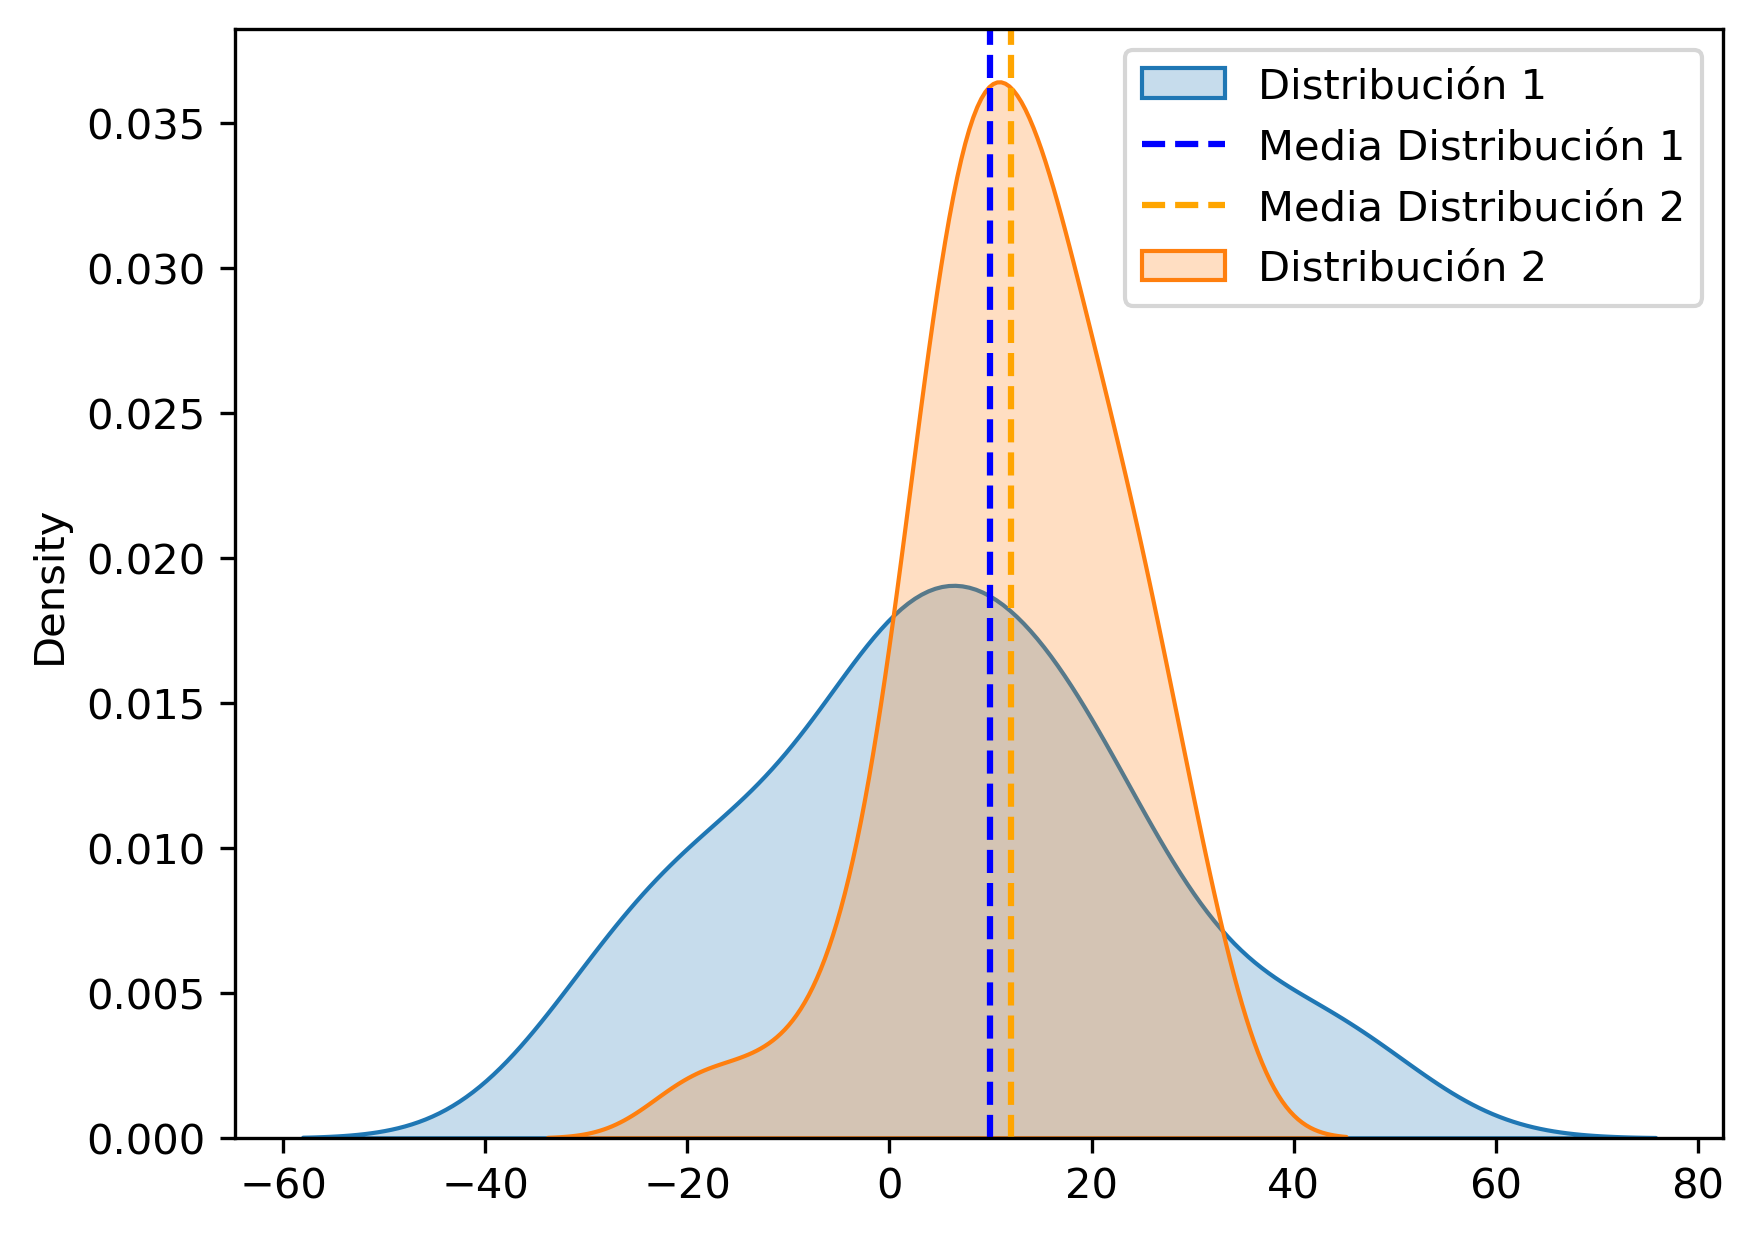

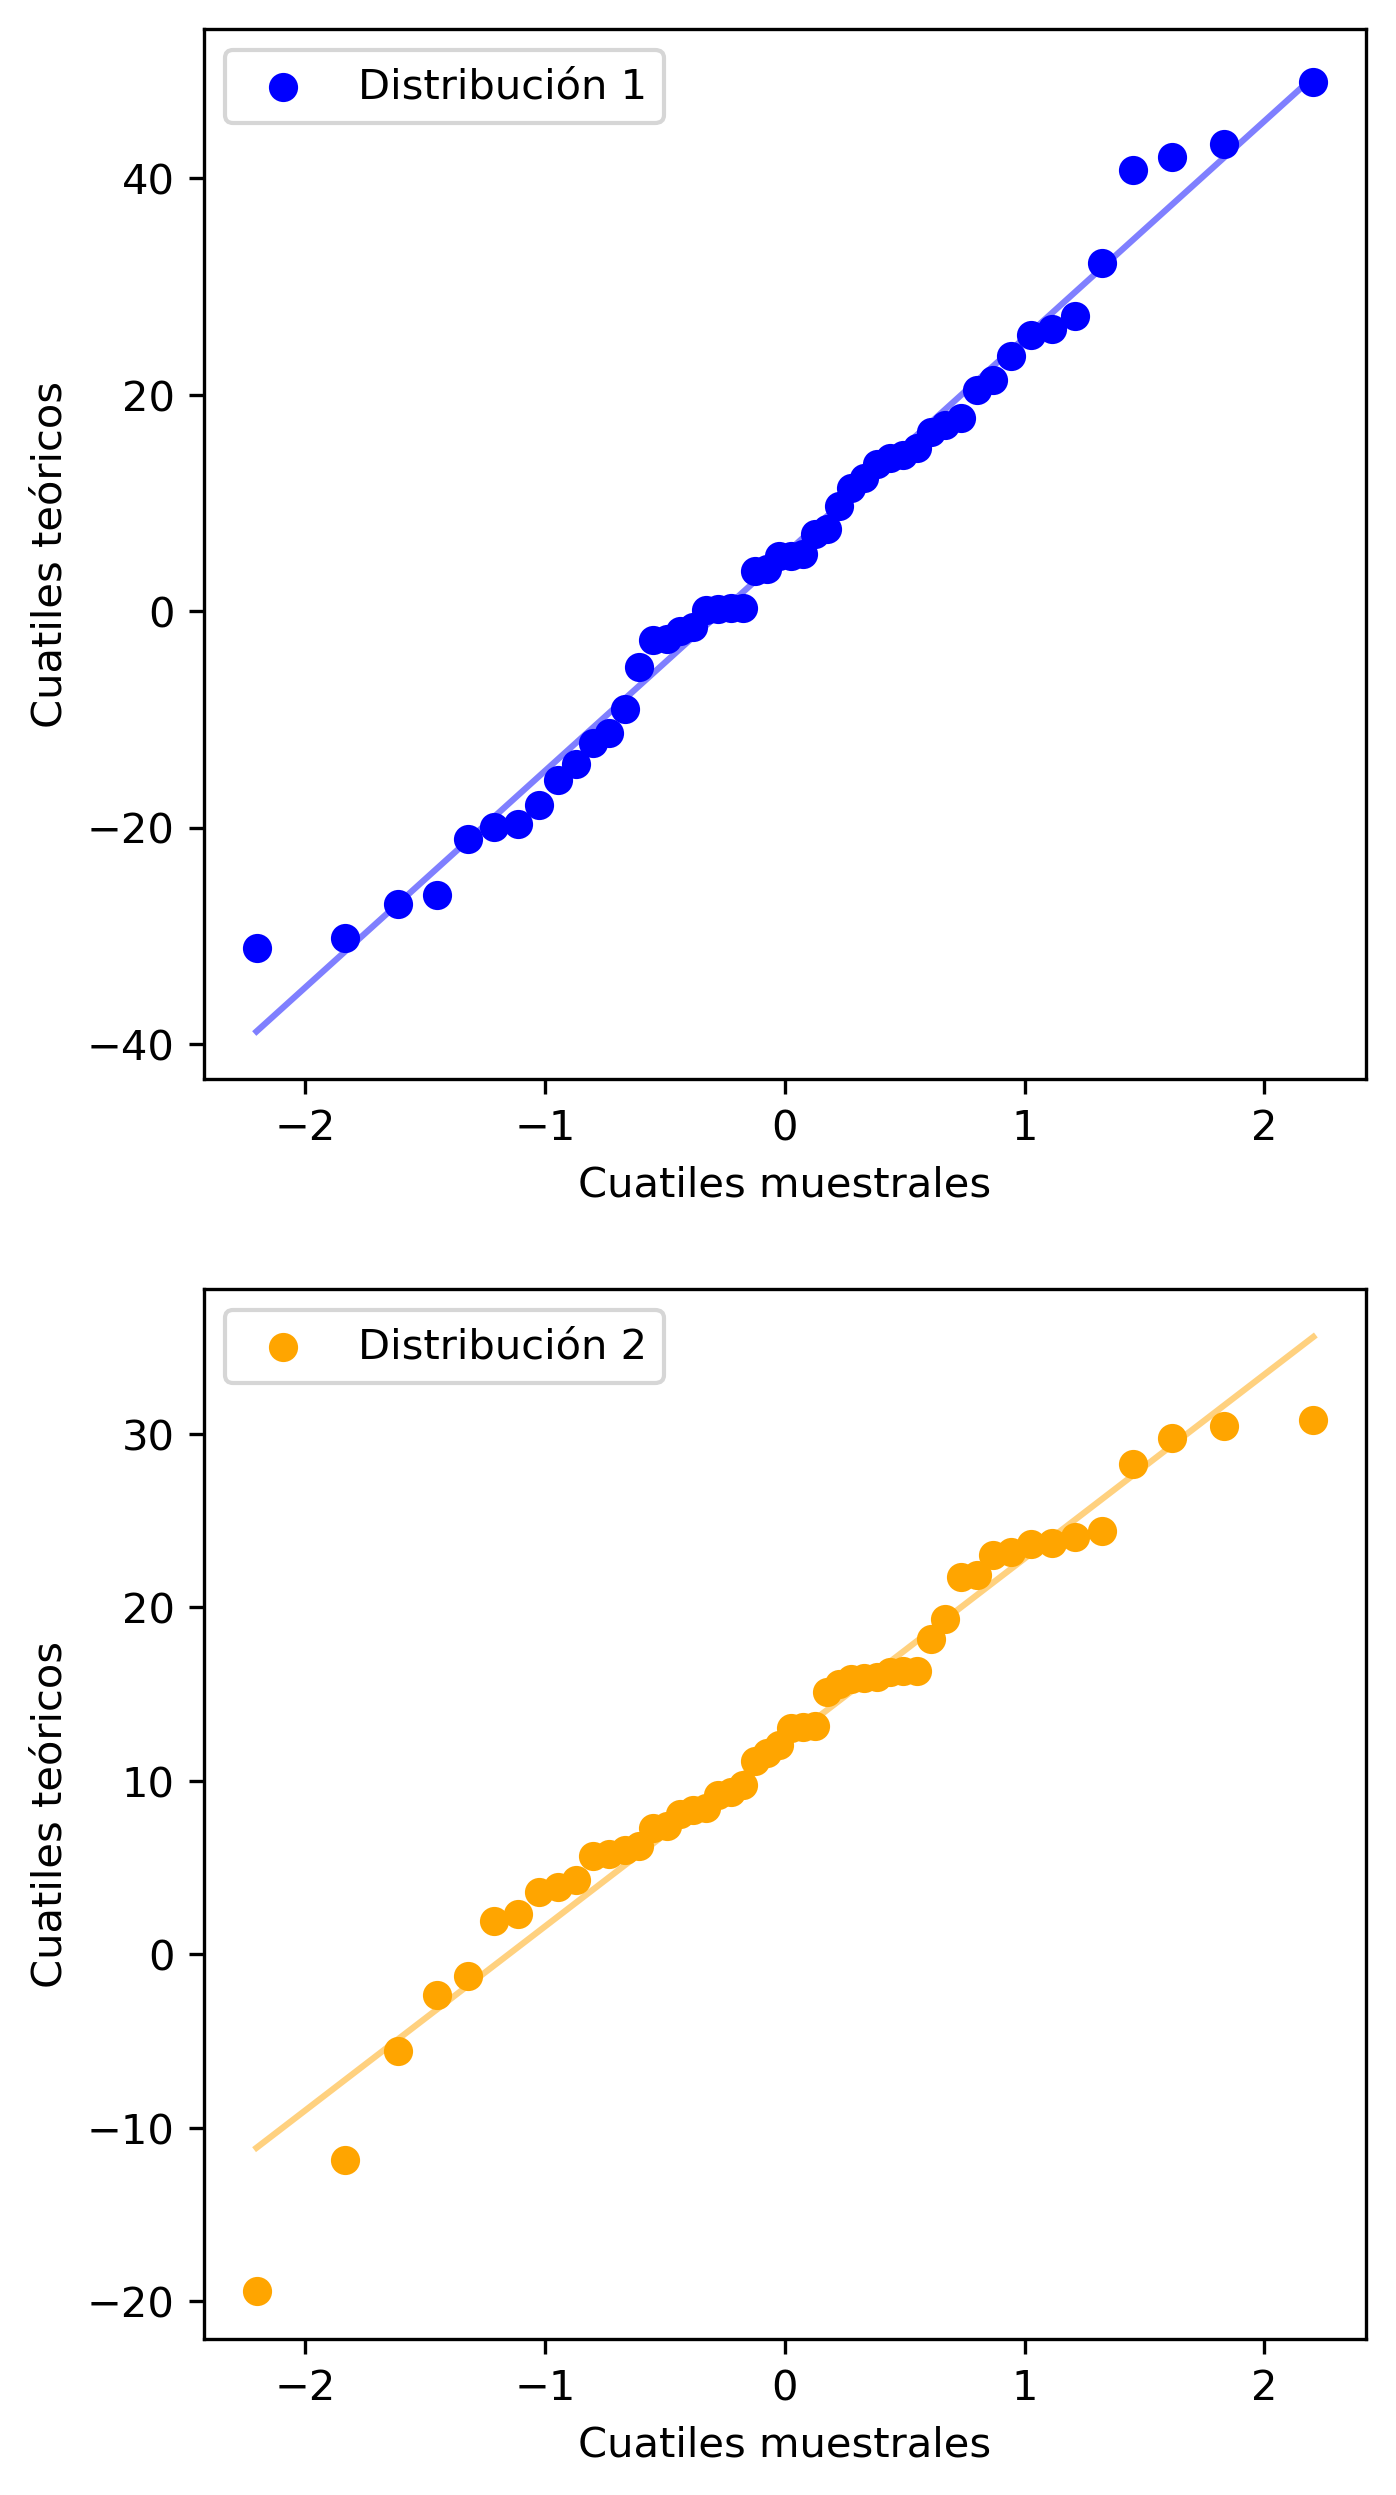

In [14]:
np.random.seed(42)
# graficamos
data1 = np.random.normal(loc = 10, scale = 21, size = 50)
data2 = np.random.normal(loc = 12, scale = 12, size = 50)

fig, ax = plt.subplots(dpi = 300)
sns.kdeplot(data1, ax=ax, label='Distribución 1', fill=True)
ax.axvline(x=10, color='blue', linestyle='--', label = 'Media Distribución 1')
ax.axvline(x=12, color='orange', linestyle='--', label = 'Media Distribución 2')
sns.kdeplot(data2, ax=ax, label='Distribución 2', fill=True)
ax.legend(loc='upper right')
plt.show()

fig, ax = plt.subplots(2,1,dpi = 300, figsize = (5, 10))
(osm, osr), (slope, intercept, r) = stats.probplot(data1)
ax[0].scatter(osm, osr, label = 'Distribución 1', color = 'blue')
ax[0].plot(osm, osm*slope + intercept, color = 'blue', alpha = 0.5)
ax[0].set_xlabel('Cuatiles muestrales')
ax[0].set_ylabel('Cuatiles teóricos')
(osm, osr), (slope, intercept, r) = stats.probplot(data2)
ax[1].scatter(osm, osr, label = 'Distribución 2', color = 'orange')
ax[1].set_xlabel('Cuatiles muestrales')
ax[1].set_ylabel('Cuatiles teóricos')
ax[1].plot(osm, osm*slope + intercept, color = 'orange', alpha = 0.5)
ax[0].legend()
ax[1].legend()
plt.show()

### 1.

Plantee una hipótesis que le permita comparar la media de ambas poblaciones.
Asuma que ambos datos son independientes y provienen de una misma población con desviación estándar ($\sigma  = 15$).

---
Respuesta:

A sabiendas que siguen una distribución cercana a la normal, con desviación estándar conocida, e indenpendencia. Podemos aplicar un test z-testats.

$H_0: \mu_1 = \mu_2$

$H_a: \mu_1 \neq \mu_2$



In [15]:
def ztest_2samp(dato1, dato2, pop_var1 = 1, pop_var2 = 1, alternative = 'two-sided'):
    '''
    Z-test para comparar dos poblaciones.
    Este test asume varianzas poblacionales conocidas, que las muestras son independientes
    y siguen una distribución normal.
    ---
    Parámetros:
        dato1 : array_like
            Primera muestra de datos.
        dato2 : array_like
            Segunda muestra de datos.
        pop_var1 : float, optional
            Varianza poblacional de la primera muestra. Por defecto es 1.
        pop_var2 : float, optional
            Varianza poblacional de la segunda muestra. Por defecto es 1.
        alternative : str, optional
            Tipo de test de hipótesis a realizar. Puede ser 'two-sided', 'larger' o 'smaller'.
            Por defecto es 'two-sided'.
    Retorna:
        z : float
            Valor del estadístico z.
        p_value : float
            Valor p del testats.
    ---
    Ejemplo de uso:
    > dato1 = [5, 7, 8, 6, 9]
    > dato2 = [4, 6, 7, 5, 8]
    > pop_var1 = 2
    > pop_var2 = 3
    > z, p_value = ztest_2samp(dato1, dato2, pop_var1, pop_var2, alternative='greater')
    '''
    mean1 = np.mean(dato1) # media muestra 1
    mean2 = np.mean(dato2) # media muestra 2

    n1 = len(dato1) # tamaño muestra 1
    n2 = len(dato2) # tamaño muestra 2


    z = (mean1 - mean2)/ np.sqrt(pop_var1/n1 + pop_var2/n2) # estadistico z

    # calculamos el valor p dependiendo del tipo de test de hipótesis
    if alternative == 'two-sided':
        p_value = 2 * (1 - stats.norm.cdf(np.abs(z)))
    elif alternative == 'larger':
        p_value = 1 - stats.norm.cdf(z)
    elif alternative == 'smaller':
        p_value = stats.norm.cdf(z)
    else:
        raise ValueError("El valor de 'alternative' debe ser 'two-sided', 'larger' o 'smaller'.")

    return z, p_value


In [16]:
z, p_value = ztest_2samp(data1, data2,
                          pop_var1 = 15**2, pop_var2 = 15**2,alternative='two-sided')
print(f'Valor del estadístico z: {z}')
print(f'Valor p del test: {p_value}') # sabemos que son no-iguales

Valor del estadístico z: -2.316107485331457
Valor p del test: 0.02055240071054487


Sabiendo $\mu_1 \neq \mu_2$ aplicamos $\mu_1 >\mu_2$.

In [17]:
z, p_value = ztest_2samp(data1, data2,
                          pop_var1 = 15**2, pop_var2 = 15**2,alternative='larger')
print(f'Valor del estadístico z: {z}')
print(f'Valor p del test: {p_value}')

Valor del estadístico z: -2.316107485331457
Valor p del test: 0.9897237996447276


Como p-value $> \alpha$ rechazamos la hipótesis alternaviva. Y probamos el otro caso $\mu_1 < \mu_2$.


In [18]:
z, p_value = ztest_2samp(data1, data2,
                          pop_var1 = 15**2, pop_var2 = 15**2, alternative='smaller')
print(f'Valor del estadístico z: {z}')
print(f'Valor p del test: {p_value}')

Valor del estadístico z: -2.316107485331457
Valor p del test: 0.01027620035527239


Pero aquí hay algo raro. No cuadra con los datos que tenemos. ¿Qué es lo que está erroneo aquí?
Notemos que la población de los datos, tienen desviaciones estándar diferentes, por lo cuál hay que modificar la prueba para asignar estas diferencias. Convenientemente, el código de más arriva, la función `ztest_2samp` es capaz de trabajar con varianzas diferentes.

In [19]:
z, p_val = ztest_2samp(data1, data2,
                        pop_var1 = 21**2, pop_var2 = 12**2, alternative='two-sided')
print('----two-sided----')
print(f'Valor del estadístico z: {z}')
print(f'Valor p del test: {p_val}')
z, p_val = ztest_2samp(data1, data2,
                        pop_var1 = 21**2, pop_var2 = 12**2, alternative='larger')
print('----one sided (>)----')
print(f'Valor del estadístico z: {z}')
print(f'Valor p del test: {p_val}')
z, p_val = ztest_2samp(data1, data2,
                        pop_var1 = 21**2, pop_var2 = 12**2, alternative='smaller')
print('----one sided (<)----')
print(f'Valor del estadístico z: {z}')
print(f'Valor p del test: {p_val}')


----two-sided----
Valor del estadístico z: -2.0313606435869915
Valor p del test: 0.04221842372946982
----one sided (>)----
Valor del estadístico z: -2.0313606435869915
Valor p del test: 0.9788907881352651
----one sided (<)----
Valor del estadístico z: -2.0313606435869915
Valor p del test: 0.021109211864734877


### 2.
Realice un test bajo la misma hipótesis salvo que ahora usted no conoce la desviación estándar de la población.

---
Respuesta:

Bajo la misma hipótesis

$H_0: \mu_1 = \mu_2$

$H_a: \mu_1 < \mu_2$

Realizamos un testats. En este caso, no conocemos la desviación estándar de la población, así que aproximamos mediante un t-testats.

In [20]:
# recordemos que ttest_ind permite comparar dos muestras independientes, 
# asumiendo que las varianzas poblacionales son desconocidas y pueden ser iguales o no.
t_test = stats.ttest_ind(data1, data2, equal_var=False, alternative= 'two-sided')
print(f'-----Two-sided-----')
print(f'Valor del estadístico t: {t_test.statistic}')
print(f'Valor p del test: {t_test.pvalue}')

print(f'-----One-sided (>)-----')
t_test = stats.ttest_ind(data1, data2, equal_var=False, alternative= 'greater')
print(f'Valor del estadístico t: {t_test.statistic}')
print(f'Valor p del test: {t_test.pvalue}')
print(f'-----One-sided (<)-----')
t_test = stats.ttest_ind(data1, data2, equal_var=False, alternative= 'less')
print(f'Valor del estadístico t: {t_test.statistic}')
print(f'Valor p del test: {t_test.pvalue}')



-----Two-sided-----
Valor del estadístico t: -2.209401913798394
Valor p del test: 0.030201896447310812
-----One-sided (>)-----
Valor del estadístico t: -2.209401913798394
Valor p del test: 0.9848990517763446
-----One-sided (<)-----
Valor del estadístico t: -2.209401913798394
Valor p del test: 0.015100948223655406


Resultados que son consistentes con los resultados de utilizar una prueba Z-test.

### 3.

Relajando aún más los supuestos, ahora los datos no son independientes. Realice un test de hipótesis respecto a la diferencia de estos datos.

---
Respuesta:

Bajo la misma hipótesis

$H_0: \mu_1 = \mu_2$

$H_a: \mu_1 < \mu_2$

Realizamos un testats. En este caso, no conocemos la desviación estándar de la población, así que aproximamos mediante un t-test, salvo que en este caso utilizamos un t-test pareado.


In [21]:
# recordemos que ttest_rel permite comparar dos muestras relacionadas o pareadas, 
# asumiendo que las varianzas poblacionales son desconocidas y pueden ser iguales o no.
t_pareado = stats.ttest_rel(data1, data2, alternative='two-sided')
print(f'-----Two-sided-----')
print(f'Valor del estadístico t: {t_pareado.statistic}')
print(f'Valor p del test: {t_pareado.pvalue}')

print(f'-----One-sided (>)-----')
t_pareado = stats.ttest_rel(data1, data2, alternative='greater')
print(f'Valor del estadístico t: {t_pareado.statistic}')
print(f'Valor p del test: {t_pareado.pvalue}')

print(f'-----One-sided (<)-----')
t_pareado = stats.ttest_rel(data1, data2, alternative='less')
print(f'Valor del estadístico t: {t_pareado.statistic}')
print(f'Valor p del test: {t_pareado.pvalue}')

-----Two-sided-----
Valor del estadístico t: -2.31809343158795
Valor p del test: 0.024661276697341136
-----One-sided (>)-----
Valor del estadístico t: -2.31809343158795
Valor p del test: 0.9876693616513295
-----One-sided (<)-----
Valor del estadístico t: -2.31809343158795
Valor p del test: 0.012330638348670568


## Datos 2



```
np.random.seed(42)
data1 = np.random.lognormal(size = 50)
data2 = np.random.laplace(size = 50)
```



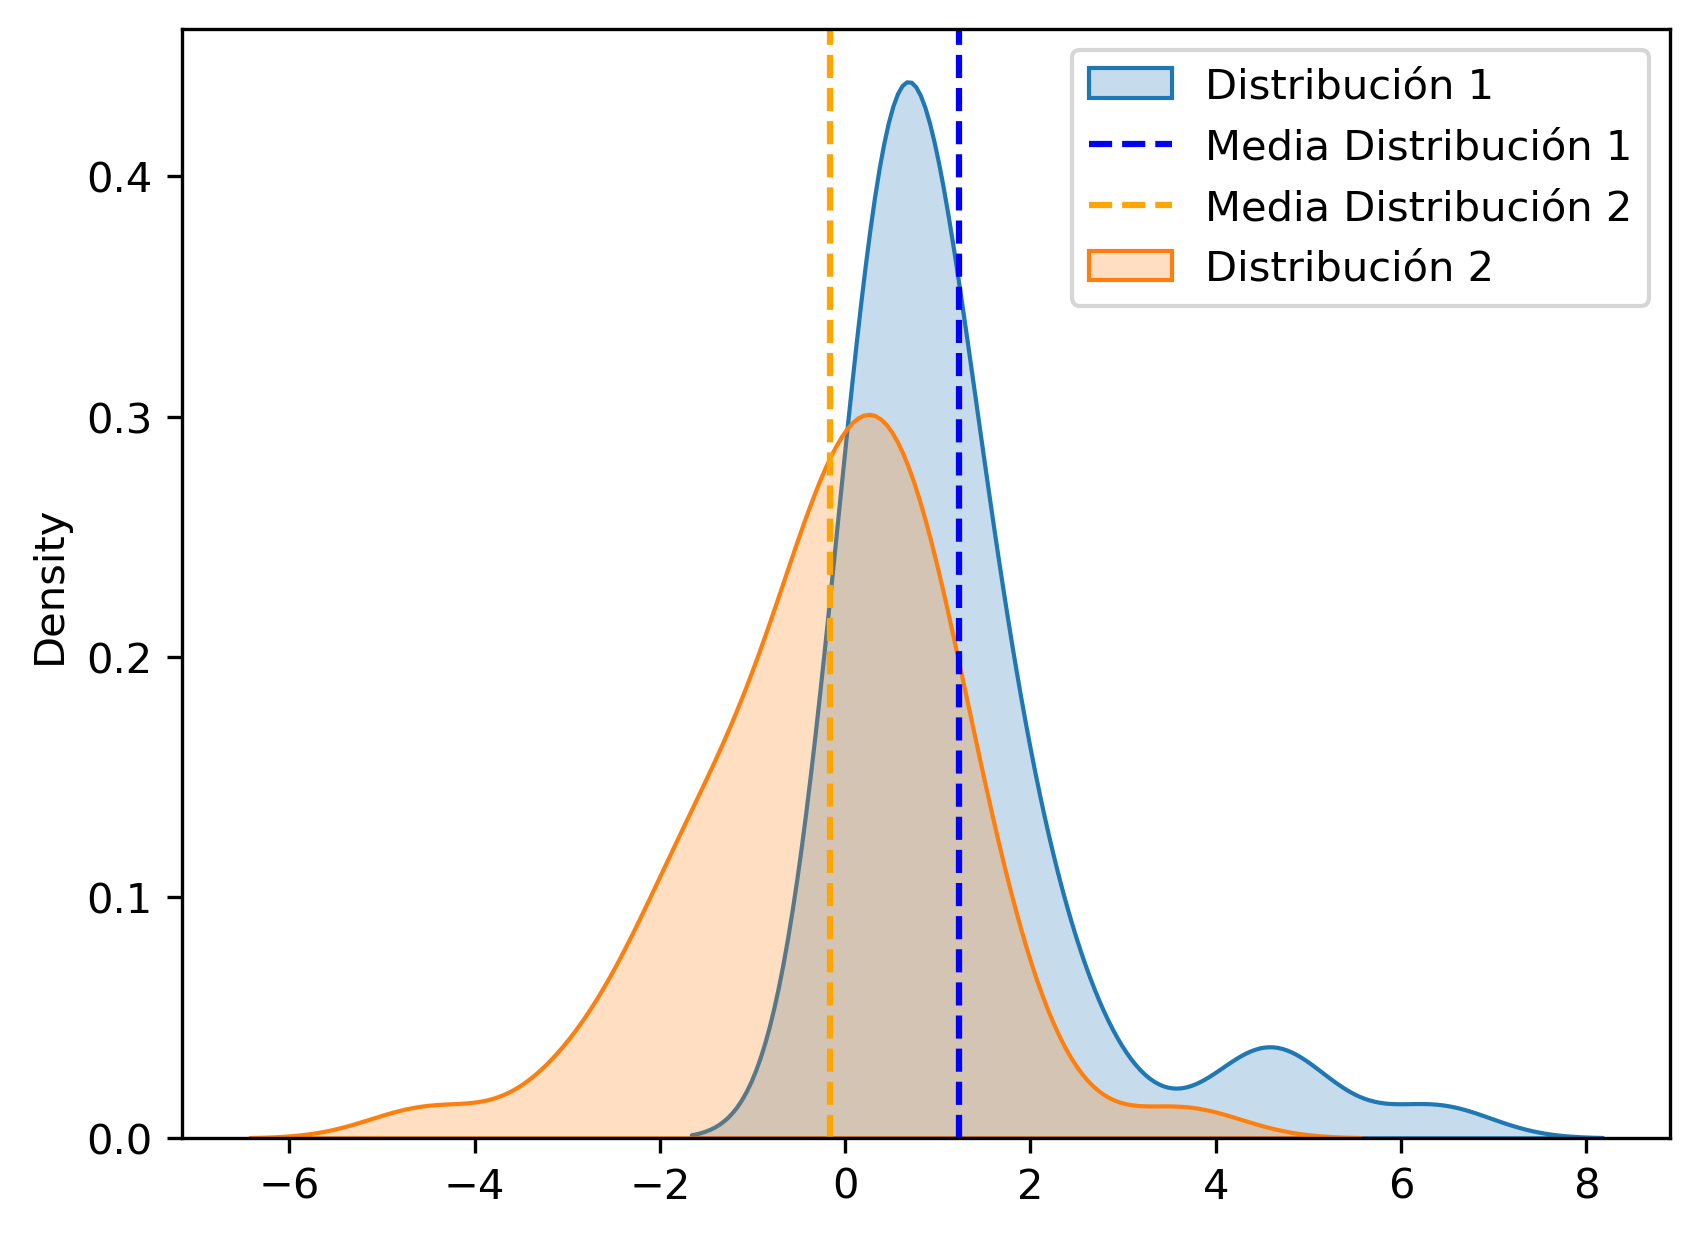

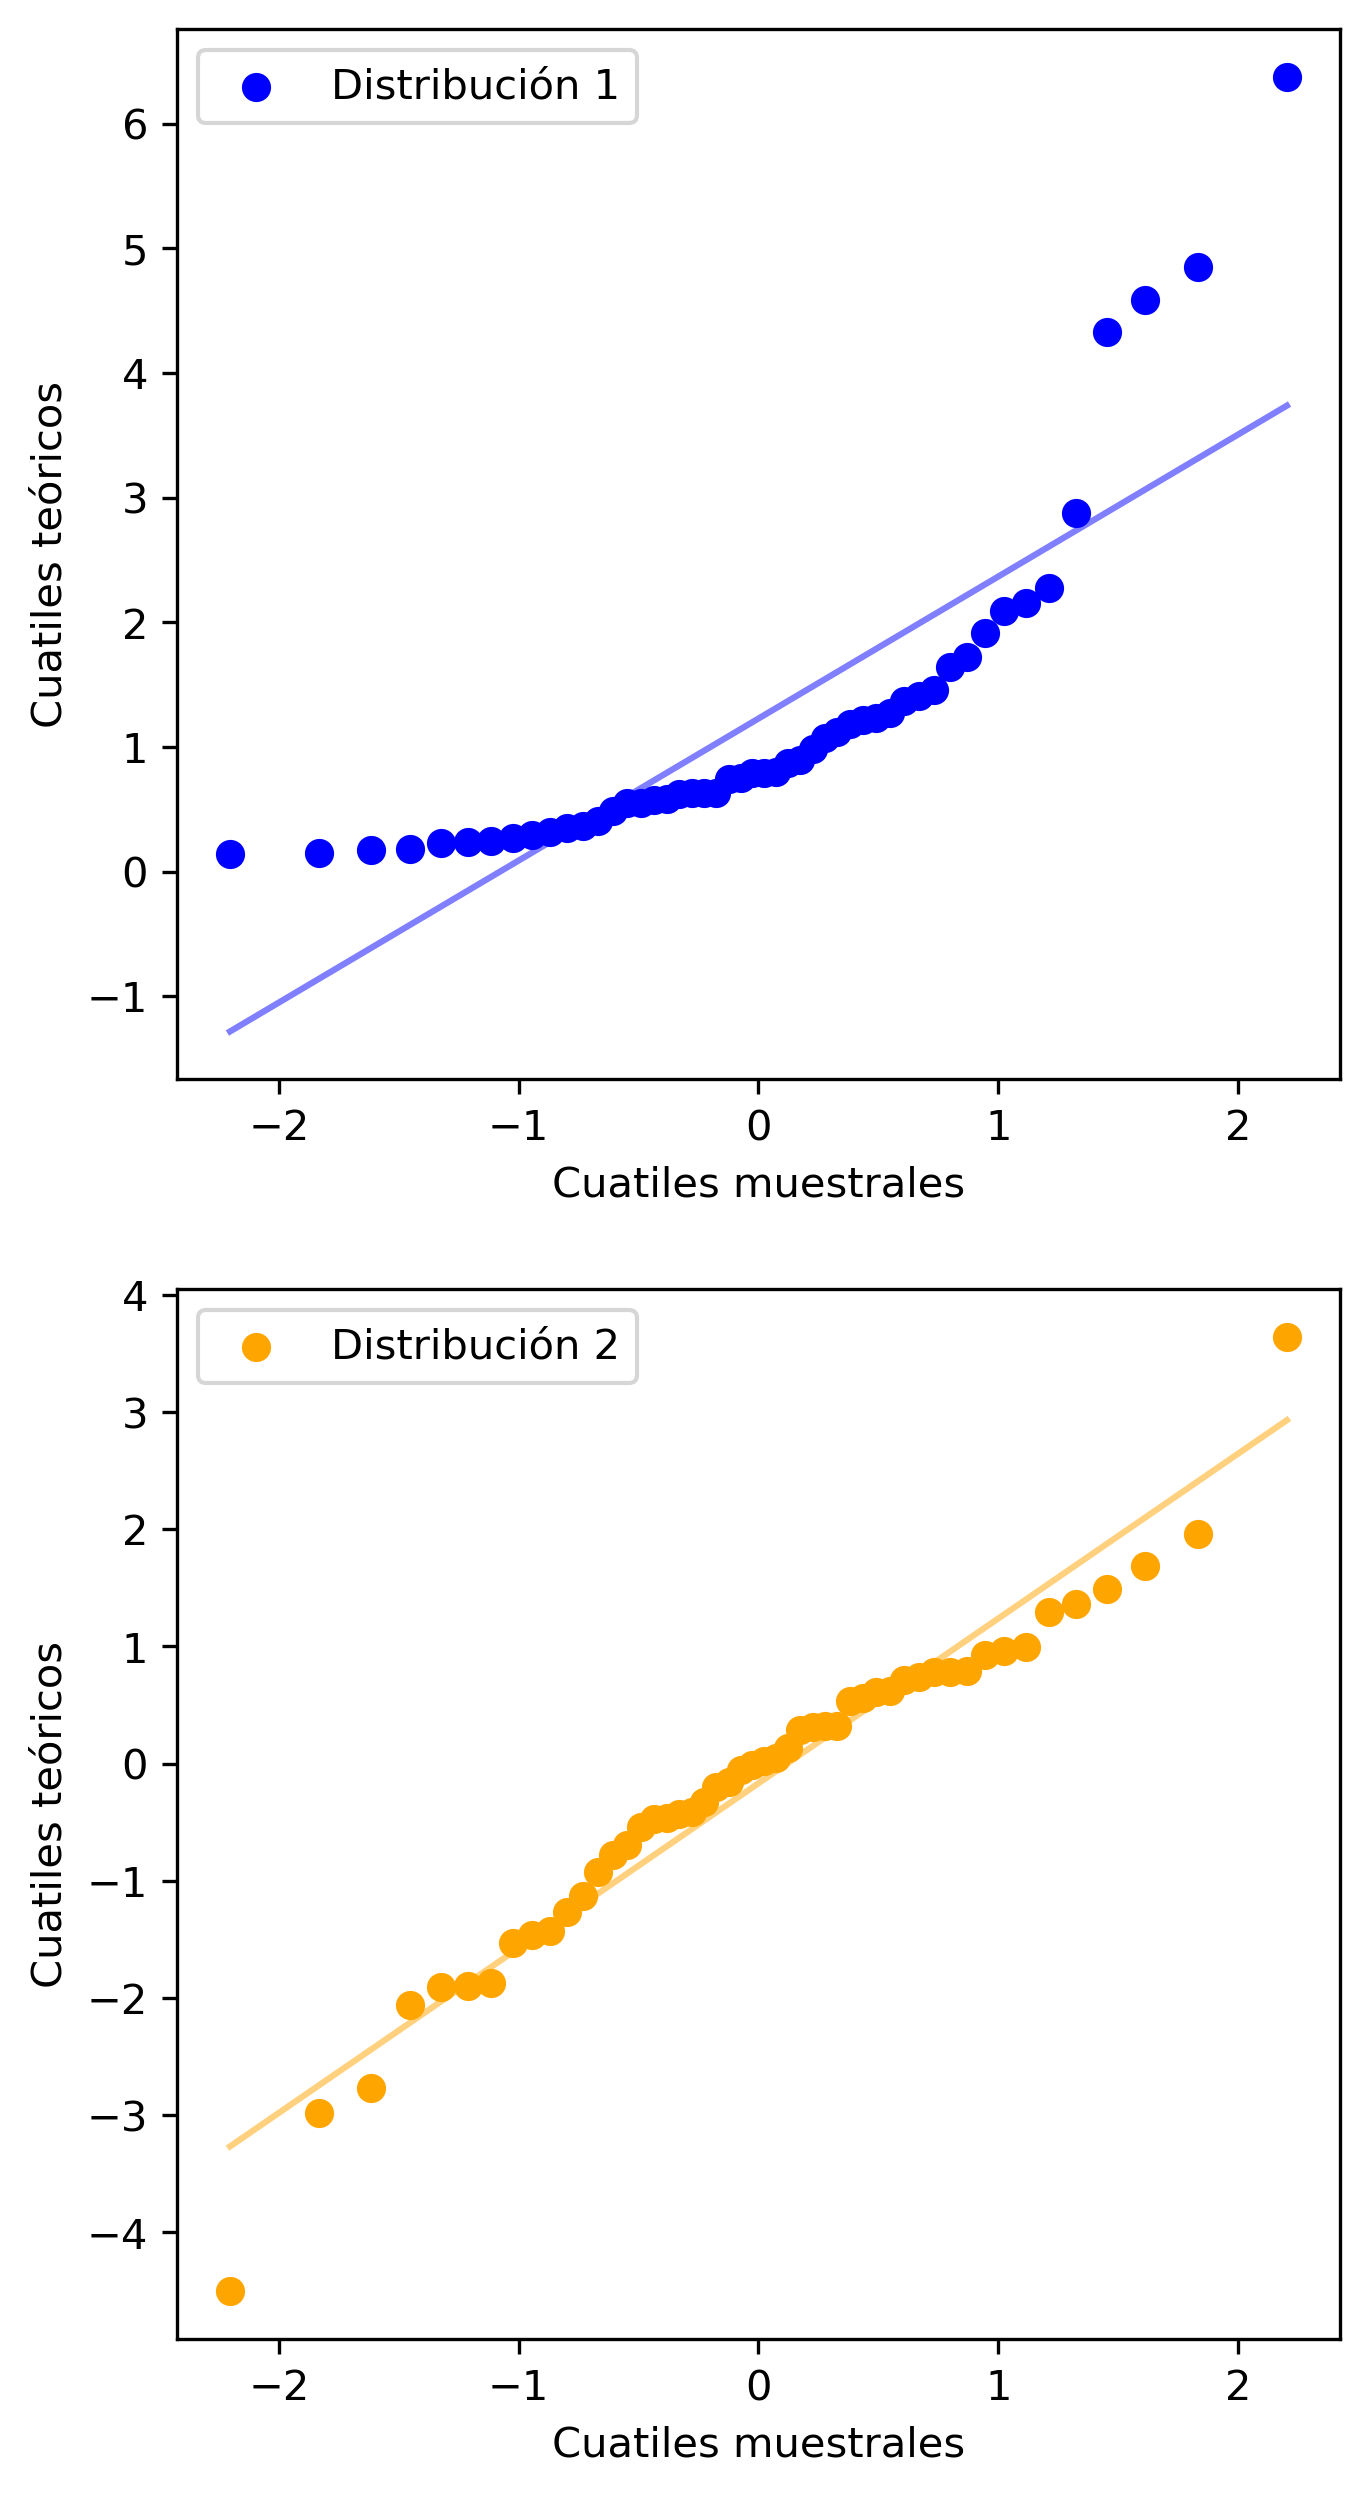

In [22]:
np.random.seed(42)
data1 = np.random.lognormal(size = 50)
data2 = np.random.laplace(size = 50)

fig, ax = plt.subplots(dpi = 300)
sns.kdeplot(data1, ax=ax, label='Distribución 1', fill=True)
mean1 = np.mean(data1)
ax.axvline(x=mean1, color='blue', linestyle='--', label = 'Media Distribución 1')
mean2 = np.mean(data2)
ax.axvline(x=mean2, color='orange', linestyle='--', label = 'Media Distribución 2')
sns.kdeplot(data2, ax=ax, label='Distribución 2', fill=True)
ax.legend(loc='upper right')
plt.show()


fig, ax = plt.subplots(2,1,dpi = 300, figsize = (5, 10))
(osm, osr), (slope, intercept, r) = stats.probplot(data1)
ax[0].scatter(osm, osr, label = 'Distribución 1', color = 'blue')
ax[0].plot(osm, osm*slope + intercept, color = 'blue', alpha = 0.5)
ax[0].set_xlabel('Cuatiles muestrales')
ax[0].set_ylabel('Cuatiles teóricos')
(osm, osr), (slope, intercept, r) = stats.probplot(data2)
ax[1].scatter(osm, osr, label = 'Distribución 2', color = 'orange')
ax[1].set_xlabel('Cuatiles muestrales')
ax[1].set_ylabel('Cuatiles teóricos')
ax[1].plot(osm, osm*slope + intercept, color = 'orange', alpha = 0.5)
ax[0].legend()
ax[1].legend()
plt.show()

Notemos que los datos NO son normales, por lo cuál ni los test-z ni los test-t son aplicables.

### 1.
Realice un test para comparar ambas muestras tomando en cuenta que quiere saber cual posee una media -o equivalente- mayor. Asuma que son independientes.

---
Respuesta:

Al ser datos que difieren de una normal, se tiene que utilizar un test no-paramétrico. De esta forma realizamos un test no-paramétrico.
Debido a que asumimos independencia el test que debemos realizar es un test Mann-Whitney U testats.

Planteamos la hipótesis

$$
H_0: \tilde{\mu_1} =   \tilde{\mu_2}
$$

$$
H_a: \tilde{\mu_1} \neq  \tilde{\mu_2}
$$


In [23]:
# el test de Mann-Whitney U es una prueba no paramétrica que se utiliza para comparar dos muestras independientes,
# especialmente cuando no se cumplen los supuestos de normalidad o homogeneidad de varianzas. 
# Este test evalúa si una muestra tiende a tener valores más altos o más bajos que
u, p_value = stats.mannwhitneyu(data1, data2, alternative='two-sided') 
print('----Two-sided----')
print(f'Valor del estadístico u: {u}')
print(f'Valor p del test: {p_value}')



----Two-sided----
Valor del estadístico u: 1954.0
Valor p del test: 1.235845998131215e-06


Así, existe evidencia suficiente para rechazar la hipótesis nula. Verificamos alternativas one-side.

$$
H_0: \tilde{\mu_1} =  \tilde{\mu_2}
$$

$$
H_a: \tilde{\mu_1} >  \tilde{\mu_2}
$$

In [24]:
u, p_value = stats.mannwhitneyu(data1, data2, alternative='greater')
print('----One-sided (>)----')
print(f'Valor del estadístico u: {u}')
print(f'Valor p del test: {p_value}')


----One-sided (>)----
Valor del estadístico u: 1954.0
Valor p del test: 6.179229990656075e-07


$$
H_0: \tilde{\mu_1} =  \tilde{\mu_2}
$$

$$
H_a: \tilde{\mu_1} <  \tilde{\mu_2}
$$

In [25]:
u, p_value = stats.mannwhitneyu(data1, data2, alternative='less')
print('----One-sided (<)----')
print(f'Valor del estadístico u: {u}')
print(f'Valor p del test: {p_value}')

----One-sided (<)----
Valor del estadístico u: 1954.0
Valor p del test: 0.9999994031971636


Por lo cual podemos afirmar que existe evidencia para rechazar la hipótesis nula, y aceptar la hipótesis alternativa $H_a: \tilde{\mu_1} >  \tilde{\mu_2}$

### 2.

Realice el mismo procedimiento pero ahora suponiendo que ambos datos están relacionados.

---
Respuesta:

Dado a que ahora los datos están relacionados, es necesarioa aplicar un test wilcoxon, el cual es la versión no-paramétrica del test-t pareado.

$$
H_0: \tilde{\mu_1} =   \tilde{\mu_2}
$$

$$
H_a: \tilde{\mu_1} \neq  \tilde{\mu_2}
$$


In [26]:
stat, pval = stats.wilcoxon(data1, data2, alternative='two-sided')
print('----Two-sided----')
print(f'Valor del estadístico de Wilcoxon: {stat}')
print(f'Valor p del test: {pval}')
stat, pval = stats.wilcoxon(data1, data2, alternative='greater')
print('----One-sided (>)----')
print(f'Valor del estadístico de Wilcoxon: {stat}')
print(f'Valor p del test: {pval}')
stat, pval = stats.wilcoxon(data1, data2, alternative='less')
print('----One-sided (<)----')
print(f'Valor del estadístico de Wilcoxon: {stat}')
print(f'Valor p del test: {pval}')

----Two-sided----
Valor del estadístico de Wilcoxon: 146.0
Valor p del test: 3.0412363649645613e-07
----One-sided (>)----
Valor del estadístico de Wilcoxon: 1129.0
Valor p del test: 1.5206181824822806e-07
----One-sided (<)----
Valor del estadístico de Wilcoxon: 1129.0
Valor p del test: 0.9999998580419627



$$
H_0: \tilde{\mu_1} = \tilde{\mu_2}
$$

$$
H_a: \tilde{\mu_1} >  \tilde{\mu_2}
$$


In [27]:
stat, pval = stats.wilcoxon(data1, data2, alternative='greater')
print(f'Valor del estadístico de Wilcoxon: {stat}')
print(f'Valor p del test: {pval}')

Valor del estadístico de Wilcoxon: 1129.0
Valor p del test: 1.5206181824822806e-07



$$
H_0: \tilde{\mu_1} = \tilde{\mu_2}
$$

$$
H_a: \tilde{\mu_1} <  \tilde{\mu_2}
$$


In [28]:
stat, pval = stats.wilcoxon(data1, data2, alternative='less')
print(f'Valor del estadístico de Wilcoxon: {stat}')
print(f'Valor p del test: {pval}')

Valor del estadístico de Wilcoxon: 1129.0
Valor p del test: 0.9999998580419627


Por lo cual nos quedamos, al igual que antes, con $H_a: \tilde{\mu_1} >  \tilde{\mu_2}$